#Analysing the Impact of Major Global Central Banks on Financial Markets Using Machine Learning

## Predicting Next-Day Currency Movement
Dataset: Federal Reserve H.10 daily exchange rates (1999–2026)
Pairs: EUR/USD, GBP/USD, GBP/EUR, USD/JPY
Goal: predict whether tomorrow's exchange rate goes up (+1), down (-1) or stays flat (0)

## Stage 0: Building the dataset from the raw source
The raw data comes from the US Federal Reserve's H.10 release
(daily exchange rates), packaged at github.com/datasets/exchange-rates
as `daily.csv`. That file has one row per country per day, all quoted
against the US dollar.

Here I am building my own dataset from it:
- keep only the Euro, UK and Japan series, from 1999 onwards
  (1999 = the year the euro was introduced)
- form 4 currency pairs; three come directly from the file, and
  GBP/EUR is derived as GBP/USD ÷ EUR/USD
- compute each day's change, return, and an up/down/flat label

In [1]:
#uploading dataset
from google.colab import files
uploaded = files.upload()

Saving daily.csv to daily.csv


In [2]:
import pandas as pd
import numpy as np

# upload daily.csv to Colab first
raw = pd.read_csv("daily.csv", parse_dates=["Date"])
print("Raw file:", raw.shape)

# keep only the three countries we need, from 1999 onwards
countries = ["Euro", "United Kingdom", "Japan"]
raw = raw[raw["Country"].isin(countries)]
raw = raw[raw["Date"].dt.year >= 1999]

# drop rows where the rate is missing or not a number
raw["Exchange rate"] = pd.to_numeric(raw["Exchange rate"], errors="coerce")
raw = raw.dropna(subset=["Exchange rate"])

print("After filtering:", raw.shape)
raw.head()

Raw file: (272271, 3)
After filtering: (20703, 3)


,Date,Country,Exchange rate
63556,1999-01-04,Euro,0.8466
63557,1999-01-05,Euro,0.8503
63558,1999-01-06,Euro,0.8594
63559,1999-01-07,Euro,0.8568
63560,1999-01-08,Euro,0.8655


In [3]:
# Reshaping and building the 4 currency pair
# pivot: one row per date, one column per country
rates = raw.pivot(index="Date", columns="Country", values="Exchange rate")

# keep only dates where all three countries reported a rate
rates = rates.dropna()
print("Complete trading days:", len(rates))

# building the 4 pairs
# source conventions: Euro = USD per EUR, United Kingdom = USD per GBP,
#                     Japan = JPY per USD
pairs = pd.DataFrame(index=rates.index)
pairs["EUR/USD"] = rates["Euro"]
pairs["GBP/USD"] = rates["United Kingdom"]
pairs["GBP/EUR"] = rates["United Kingdom"] / rates["Euro"]   # derived cross-rate
pairs["USD/JPY"] = rates["Japan"]

pairs.head()

Complete trading days: 6901


,EUR/USD,GBP/USD,GBP/EUR,USD/JPY
Date,,,,
1999-01-04,0.8466,0.6031,0.712379,112.15
1999-01-05,0.8503,0.6036,0.709867,111.15
1999-01-06,0.8594,0.6043,0.703165,112.78
1999-01-07,0.8568,0.6062,0.707516,111.69
1999-01-08,0.8655,0.6096,0.704333,111.52


In [4]:
THRESHOLD = 0.0001   # moves smaller than this count as "flat"

pair_info = {
    "EUR/USD": ("EUR", "USD", "European Central Bank", "Federal Reserve"),
    "GBP/USD": ("GBP", "USD", "Bank of England", "Federal Reserve"),
    "GBP/EUR": ("GBP", "EUR", "Bank of England", "European Central Bank"),
    "USD/JPY": ("USD", "JPY", "Federal Reserve", "Bank of Japan"),
}

all_rows = []
for pair in pairs.columns:
    base, quote, base_bank, quote_bank = pair_info[pair]

    part = pd.DataFrame({
        "Date": pairs.index,
        "Currency_Pair": pair,
        "Base_Currency": base,
        "Quote_Currency": quote,
        "Exchange_Rate": pairs[pair].values,
    })
    part["Previous_Rate"] = part["Exchange_Rate"].shift(1)
    part["Absolute_Change"] = part["Exchange_Rate"] - part["Previous_Rate"]
    part["Daily_Return"] = part["Absolute_Change"] / part["Previous_Rate"]

    # label: +1 up, -1 down, 0 flat or first day
    part["Movement_Label"] = 0
    part.loc[part["Daily_Return"] > THRESHOLD, "Movement_Label"] = 1
    part.loc[part["Daily_Return"] < -THRESHOLD, "Movement_Label"] = -1

    part["Base_Central_Bank"] = base_bank
    part["Quote_Central_Bank"] = quote_bank
    all_rows.append(part)

dataset = pd.concat(all_rows).sort_values(["Currency_Pair", "Date"]).reset_index(drop=True)
dataset.to_csv("central_bank_fx_ml_dataset.csv", index=False)

print("Saved central_bank_fx_ml_dataset.csv")
print("Total records:", len(dataset))
print("Date range:", dataset["Date"].min().date(), "to", dataset["Date"].max().date())

Saved central_bank_fx_ml_dataset.csv
Total records: 27604
Date range: 1999-01-04 to 2026-07-10


 Imports and loading the data:

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("central_bank_fx_ml_dataset.csv", parse_dates=["Date"])
df = df.sort_values(["Currency_Pair", "Date"]).reset_index(drop=True)
print(df.shape)
df.head()

(27604, 11)


,Date,Currency_Pair,Base_Currency,Quote_Currency,Exchange_Rate,Previous_Rate,Absolute_Change,Daily_Return,Movement_Label,Base_Central_Bank,Quote_Central_Bank
0,1999-01-04,EUR/USD,EUR,USD,0.8466,NaN,NaN,NaN,0,European Central Bank,Federal Reserve
1,1999-01-05,EUR/USD,EUR,USD,0.8503,0.8466,0.0037,0.004370,1,European Central Bank,Federal Reserve
2,1999-01-06,EUR/USD,EUR,USD,0.8594,0.8503,0.0091,0.010702,1,European Central Bank,Federal Reserve
3,1999-01-07,EUR/USD,EUR,USD,0.8568,0.8594,-0.0026,-0.003025,-1,European Central Bank,Federal Reserve
4,1999-01-08,EUR/USD,EUR,USD,0.8655,0.8568,0.0087,0.010154,1,European Central Bank,Federal Reserve


## Step 1: Cleaning
- The first row of each currency pair has no previous rate, so we drop it

In [6]:
df = df[df["Previous_Rate"].notna()]
print(df.shape)

(27600, 11)


## Step 2: Feature engineering
We create features that only use information available up to the current day:
- Log returns (better statistical behaviour than raw prices)
- Lagged returns (what happened 1, 2, 3, 5 days ago)
- Rolling averages and volatility (5, 10, 20 day windows)
- Momentum indicators (rate of change, RSI)
- Calendar features (day of week, month)

In [7]:
# log return for the current day
df["Log_Return"] = np.log(df["Exchange_Rate"] / df["Previous_Rate"])

# group by currency pair (so calculations don't mix pairs together)
grouped = df.groupby("Currency_Pair")

# lagged returns
df["Log_Return_lag1"] = df["Log_Return"]
df["Log_Return_lag2"] = grouped["Log_Return"].shift(1)
df["Log_Return_lag3"] = grouped["Log_Return"].shift(2)
df["Log_Return_lag5"] = grouped["Log_Return"].shift(4)

# rolling statistics
for w in [5, 10, 20]:
    df[f"RollMean_{w}d"] = grouped["Log_Return"].transform(lambda s: s.rolling(w).mean())
    df[f"RollVol_{w}d"] = grouped["Log_Return"].transform(lambda s: s.rolling(w).std())

# momentum: percentage change over 5 and 10 days
df["ROC_5d"] = grouped["Exchange_Rate"].transform(lambda s: s.pct_change(5))
df["ROC_10d"] = grouped["Exchange_Rate"].transform(lambda s: s.pct_change(10))

# RSI (14 day) - a common technical indicator
def rsi(prices, period=14):
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

df["RSI_14"] = grouped["Exchange_Rate"].transform(rsi)

# calendar features
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month

df.head()

,Date,Currency_Pair,Base_Currency,Quote_Currency,Exchange_Rate,Previous_Rate,Absolute_Change,Daily_Return,Movement_Label,Base_Central_Bank,...,RollVol_5d,RollMean_10d,RollVol_10d,RollMean_20d,RollVol_20d,ROC_5d,ROC_10d,RSI_14,DayOfWeek,Month
1,1999-01-05,EUR/USD,EUR,USD,0.8503,0.8466,0.0037,0.004370,1,European Central Bank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,1999-01-06,EUR/USD,EUR,USD,0.8594,0.8503,0.0091,0.010702,1,European Central Bank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1
3,1999-01-07,EUR/USD,EUR,USD,0.8568,0.8594,-0.0026,-0.003025,-1,European Central Bank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
4,1999-01-08,EUR/USD,EUR,USD,0.8655,0.8568,0.0087,0.010154,1,European Central Bank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1
5,1999-01-11,EUR/USD,EUR,USD,0.8670,0.8655,0.0015,0.001733,1,European Central Bank,...,0.005771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


##Candlestick and Volume

In [8]:
# Display all columns in the dataset so we know what we're working with
print("Available columns in dataset:")
print(df.columns.tolist())

# Define the columns that MUST exist in our dataset for this step to work
required_cols = [
    "Date",
    "Currency_Pair",
    "Exchange_Rate",
    "Daily_Return"
]

# Check which required columns are missing from our dataframe
missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

# If any columns are missing, stop the code and tell the user which ones
if missing_cols:
    raise ValueError(
        "Missing required columns for Step 2B: "
        + ", ".join(missing_cols)
    )

# Sort the data by Currency_Pair first, then by Date to keep data organized
# reset_index(drop=True) creates a new clean index starting from 0
df = df.sort_values(
    ["Currency_Pair", "Date"]
).reset_index(drop=True)

# Create a helper function that searches for a column by trying multiple possible names
# This is useful because different datasets use different column naming conventions
def find_first_existing_column(possible_columns, dataframe):
    for col in possible_columns:
        if col in dataframe.columns:
            return col  # Return the first column name that actually exists
    return None  # If none of the names exist, return None

# Define all possible column names for Open prices (uppercase, lowercase, mixed)
possible_open_cols = ["Open", "open", "OPEN"]
# Define all possible column names for High prices
possible_high_cols = ["High", "high", "HIGH"]
# Define all possible column names for Low prices
possible_low_cols = ["Low", "low", "LOW"]
# Define all possible column names for Close prices (includes alternatives like Exchange_Rate)
possible_close_cols = [
    "Close",
    "close",
    "CLOSE",
    "Exchange_Rate",
    "Rate",
    "Value",
    "Price"
]
# Define all possible column names for Volume data
possible_volume_cols = [
    "Volume",
    "volume",
    "Tick_Volume",
    "tick_volume",
    "VOL"
]

# Try to find the actual column names in our dataset
open_col = find_first_existing_column(possible_open_cols, df)
high_col = find_first_existing_column(possible_high_cols, df)
low_col = find_first_existing_column(possible_low_cols, df)
close_col = find_first_existing_column(possible_close_cols, df)
volume_col = find_first_existing_column(possible_volume_cols, df)

# Print which columns we detected so the user can verify we found the right ones
print("\nDetected columns:")
print("Open column:", open_col)
print("High column:", high_col)
print("Low column:", low_col)
print("Close/Price column:", close_col)
print("Volume column:", volume_col)

# Check if we found all 4 OHLC columns (Open, High, Low, Close)
if (
    open_col is not None and
    high_col is not None and
    low_col is not None and
    close_col is not None
):

    print("\nTrue OHLC columns found. Creating real candlestick features.")

    # Candle Body = how much price moved from open to close
    df["Candle_Body"] = df[close_col] - df[open_col]

    # Candle Range = total price movement from lowest to highest point
    df["Candle_Range"] = df[high_col] - df[low_col]

    # Upper Wick = distance from the higher of (open/close) to the high
    df["Candle_Upper_Wick"] = (
        df[high_col] - df[[open_col, close_col]].max(axis=1)
    )

    # Lower Wick = distance from the low to the lower of (open/close)
    df["Candle_Lower_Wick"] = (
        df[[open_col, close_col]].min(axis=1) - df[low_col]
    )

    # Absolute size of the candle body (positive number regardless of direction)
    df["Candle_Body_Size"] = df["Candle_Body"].abs()

    # Ratio of body to total range (shows if body dominates the candle)
    # We use .replace(0, np.nan) to avoid division by zero
    df["Candle_Body_Ratio"] = (
        df["Candle_Body_Size"] /
        df["Candle_Range"].replace(0, np.nan)
    )

    # Ratio of upper wick to total range (shows how much upward rejection occurred)
    df["Upper_Wick_Ratio"] = (
        df["Candle_Upper_Wick"] /
        df["Candle_Range"].replace(0, np.nan)
    )

    # Ratio of lower wick to total range (shows how much downward rejection occurred)
    df["Lower_Wick_Ratio"] = (
        df["Candle_Lower_Wick"] /
        df["Candle_Range"].replace(0, np.nan)
    )

    # Flag: 1 if close > open (price went up), 0 otherwise
    df["Bullish_Candle"] = (
        df[close_col] > df[open_col]
    ).astype(int)

    # Flag: 1 if close < open (price went down), 0 otherwise
    df["Bearish_Candle"] = (
        df[close_col] < df[open_col]
    ).astype(int)

    # Doji pattern: candle body is very small (less than 10% of range)
    df["Doji_Candle"] = (
        df["Candle_Body_Ratio"] < 0.10
    ).astype(int)

    # Hammer pattern: small body on top, long lower wick (buying pressure at bottom)
    df["Hammer_Candle"] = (
        (df["Lower_Wick_Ratio"] > 0.50) &
        (df["Candle_Body_Ratio"] < 0.35)
    ).astype(int)

    # Shooting Star pattern: small body on bottom, long upper wick (selling pressure at top)
    df["Shooting_Star_Candle"] = (
        (df["Upper_Wick_Ratio"] > 0.50) &
        (df["Candle_Body_Ratio"] < 0.35)
    ).astype(int)

else:

    print("\nTrue OHLC columns not found.")
    print("Creating return-based candlestick proxy features.")

    # If we don't have OHLC data, use Daily_Return as a substitute for candle body
    df["Candle_Body"] = df["Daily_Return"]

    # Absolute value of daily return
    df["Candle_Body_Size"] = df["Daily_Return"].abs()

    # Use the return as a proxy for the entire range
    df["Candle_Range"] = df["Daily_Return"].abs()

    # We don't have wick data without OHLC, so set these to 0
    df["Candle_Upper_Wick"] = 0.0
    df["Candle_Lower_Wick"] = 0.0

    # If we're using returns, body is always 100% of the range
    df["Candle_Body_Ratio"] = 1.0
    df["Upper_Wick_Ratio"] = 0.0
    df["Lower_Wick_Ratio"] = 0.0

    # Bullish: return is positive
    df["Bullish_Candle"] = (
        df["Daily_Return"] > 0
    ).astype(int)

    # Bearish: return is negative
    df["Bearish_Candle"] = (
        df["Daily_Return"] < 0
    ).astype(int)

    # For Doji: find the 10th percentile of absolute returns per currency pair
    # and mark small moves as doji candles
    doji_threshold = (
        df.groupby("Currency_Pair")["Daily_Return"]
        .transform(lambda x: x.abs().quantile(0.10))
    )

    df["Doji_Candle"] = (
        df["Daily_Return"].abs() <= doji_threshold
    ).astype(int)

    # Without real OHLC, we can't detect hammer/shooting star patterns, so set to 0
    df["Hammer_Candle"] = 0
    df["Shooting_Star_Candle"] = 0

# If volume data exists, create volume-based features
if volume_col is not None:

    print("\nVolume column found. Creating volume-based features.")

    # Convert volume to numeric (in case there are text values), replace errors with NaN
    df["Volume_Feature"] = pd.to_numeric(
        df[volume_col],
        errors="coerce"
    )

    # Calculate percentage change in volume compared to previous day
    # groupby ensures we only compare within the same currency pair
    df["Volume_Change"] = (
        df.groupby("Currency_Pair")["Volume_Feature"]
        .pct_change()
    )

    # Calculate 5-day rolling average of volume (moving average)
    df["Rolling_Volume_5"] = (
        df.groupby("Currency_Pair")["Volume_Feature"]
        .rolling(window=5)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Calculate 10-day rolling average of volume
    df["Rolling_Volume_10"] = (
        df.groupby("Currency_Pair")["Volume_Feature"]
        .rolling(window=10)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Flag high volume days: 1 if volume is above the median for that currency pair
    df["High_Volume_Flag"] = (
        df["Volume_Feature"] >
        df.groupby("Currency_Pair")["Volume_Feature"].transform("median")
    ).astype(int)

else:

    print("\nNo true volume column found.")
    print("Creating market activity proxy from absolute daily return.")

    # Use absolute return as a proxy for market activity/volatility
    df["Activity_Proxy"] = df["Daily_Return"].abs()

    # 5-day rolling average of market activity
    df["Rolling_Activity_5"] = (
        df.groupby("Currency_Pair")["Activity_Proxy"]
        .rolling(window=5)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # 10-day rolling average of market activity
    df["Rolling_Activity_10"] = (
        df.groupby("Currency_Pair")["Activity_Proxy"]
        .rolling(window=10)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # Flag high activity days
    df["High_Activity_Flag"] = (
        df["Activity_Proxy"] >
        df.groupby("Currency_Pair")["Activity_Proxy"].transform("median")
    ).astype(int)

# Remove any infinity values (positive or negative) and replace with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Sort again to make sure everything is in order (important after all our calculations)
df = df.sort_values(
    ["Currency_Pair", "Date"]
).reset_index(drop=True)

# Forward fill then backward fill: this handles NaN values by using nearby values
# ffill() fills down, bfill() fills up - this handles gaps in the data
df = df.ffill().bfill()

# List of all candlestick feature column names we created
candlestick_cols = [
    "Candle_Body",
    "Candle_Body_Size",
    "Candle_Range",
    "Candle_Upper_Wick",
    "Candle_Lower_Wick",
    "Bullish_Candle",
    "Bearish_Candle",
    "Doji_Candle",
    "Hammer_Candle",
    "Shooting_Star_Candle"
]

# List of all volume/activity columns that actually exist in our dataframe
activity_cols = [
    col for col in [
        "Volume_Feature",
        "Volume_Change",
        "Rolling_Volume_5",
        "Rolling_Volume_10",
        "High_Volume_Flag",
        "Activity_Proxy",
        "Rolling_Activity_5",
        "Rolling_Activity_10",
        "High_Activity_Flag"
    ]
    if col in df.columns
]

# Print success message and show final dataset dimensions
print("\nCandlestick and volume/activity features added successfully.")
print("Dataset shape after Step 2B:", df.shape)

# Display first few rows with Date, Currency_Pair, and all our new features
display(
    df[
        ["Date", "Currency_Pair"] +
        candlestick_cols +
        activity_cols
    ].head()
)

Available columns in dataset:
['Date', 'Currency_Pair', 'Base_Currency', 'Quote_Currency', 'Exchange_Rate', 'Previous_Rate', 'Absolute_Change', 'Daily_Return', 'Movement_Label', 'Base_Central_Bank', 'Quote_Central_Bank', 'Log_Return', 'Log_Return_lag1', 'Log_Return_lag2', 'Log_Return_lag3', 'Log_Return_lag5', 'RollMean_5d', 'RollVol_5d', 'RollMean_10d', 'RollVol_10d', 'RollMean_20d', 'RollVol_20d', 'ROC_5d', 'ROC_10d', 'RSI_14', 'DayOfWeek', 'Month']

Detected columns:
Open column: None
High column: None
Low column: None
Close/Price column: Exchange_Rate
Volume column: None

True OHLC columns not found.
Creating return-based candlestick proxy features.

No true volume column found.
Creating market activity proxy from absolute daily return.

Candlestick and volume/activity features added successfully.
Dataset shape after Step 2B: (27600, 44)


,Date,Currency_Pair,Candle_Body,Candle_Body_Size,Candle_Range,Candle_Upper_Wick,Candle_Lower_Wick,Bullish_Candle,Bearish_Candle,Doji_Candle,Hammer_Candle,Shooting_Star_Candle,Activity_Proxy,Rolling_Activity_5,Rolling_Activity_10,High_Activity_Flag
0,1999-01-05,EUR/USD,0.004370,0.004370,0.004370,0.0,0.0,1,0,0,0,0,0.004370,0.005997,0.005493,1
1,1999-01-06,EUR/USD,0.010702,0.010702,0.010702,0.0,0.0,1,0,0,0,0,0.010702,0.005997,0.005493,1
2,1999-01-07,EUR/USD,-0.003025,0.003025,0.003025,0.0,0.0,0,1,0,0,0,0.003025,0.005997,0.005493,0
3,1999-01-08,EUR/USD,0.010154,0.010154,0.010154,0.0,0.0,1,0,0,0,0,0.010154,0.005997,0.005493,1
4,1999-01-11,EUR/USD,0.001733,0.001733,0.001733,0.0,0.0,1,0,0,0,0,0.001733,0.005997,0.005493,0


## Explanation
In this code, I validate my financial dataset and create trading features from currency pair data. First, I check that all required columns exist (Date, Currency_Pair, Exchange_Rate, Daily_Return) and sort the data by currency pair and date. Since different datasets use different column names, I created a flexible function that searches for columns by trying multiple naming conventions (like "Close", "close", or "Exchange_Rate"). If I have real OHLC data (Open, High, Low, Close), I calculate candlestick features including the body, wicks, and patterns like Doji, Hammer, and Shooting Star that traders use to identify market signals. When OHLC data isn't available, I use Daily_Return as a proxy instead. For volume data, I create features like rolling averages and high-volume flags to track market activity, or use absolute returns as an activity proxy if volume isn't available. Finally, I clean the data by removing infinite values and filling gaps with forward and backward filling, then display the new features to verify everything worked correctly.

###Candlestick Pattern Visualisation

Selected currency pair for candlestick visualisation: EUR/USD


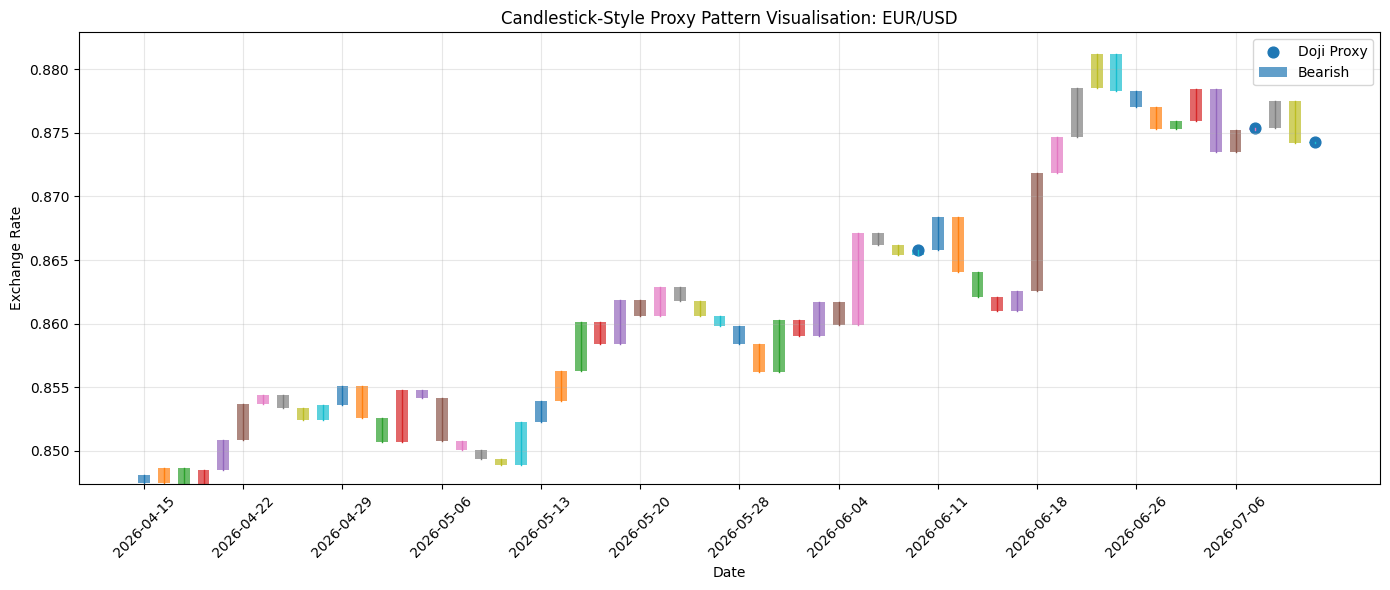


Candlestick-style proxy pattern counts for EUR/USD


,Count
Bullish_Candle,30
Bearish_Candle,30
Doji_Candle,3
Hammer_Candle,0
Shooting_Star_Candle,0


In [9]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Defining all the columns I need for this visualization to work
required_visual_cols = [
    "Date",
    "Currency_Pair",
    "Exchange_Rate",
    "Daily_Return",
    "Bullish_Candle",
    "Bearish_Candle",
    "Doji_Candle"
]

# Checking which columns I'm missing from my dataframe
missing_visual_cols = [
    col for col in required_visual_cols
    if col not in df.columns
]

# If I'm missing any columns, stop and tell me which ones
if missing_visual_cols:
    raise ValueError(
        "Missing columns for candlestick visualisation: "
        + ", ".join(missing_visual_cols)
        + ". Please run Step 2B first."
    )

# Setting the currency pair I want to visualize
selected_pair = "EUR/USD"

# If EUR/USD doesn't exist in my data, I use the first currency pair available
if selected_pair not in df["Currency_Pair"].unique():
    selected_pair = df["Currency_Pair"].unique()[0]

# Print which currency pair I'm analyzing
print("Selected currency pair for candlestick visualisation:", selected_pair)

# Filter my data to only include the selected currency pair, sort by date, and get the last 60 rows
plot_df = (
    df[df["Currency_Pair"] == selected_pair]
    .sort_values("Date")
    .tail(60)
    .copy()
    .reset_index(drop=True)
)

# Convert Date column to datetime format so I can format it nicely
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

# Create x-axis positions (0, 1, 2, ... for each candle)
x = np.arange(len(plot_df))

# Set the close price as the actual exchange rate
plot_df["Proxy_Close"] = plot_df["Exchange_Rate"]

# Calculate the open price by reversing the daily return calculation
# If return = (close - open) / open, then open = close / (1 + return)
plot_df["Proxy_Open"] = (
    plot_df["Exchange_Rate"] /
    (1 + plot_df["Daily_Return"])
)

# Set high price as the maximum between open and close
plot_df["Proxy_High"] = plot_df[["Proxy_Open", "Proxy_Close"]].max(axis=1)

# Set low price as the minimum between open and close
plot_df["Proxy_Low"] = plot_df[["Proxy_Open", "Proxy_Close"]].min(axis=1)

# Create a figure with size 14 inches wide and 6 inches tall
plt.figure(figsize=(14, 6))

# Loop through each candle and draw it
for i in range(len(plot_df)):

    # Get the price values for this candle
    open_price = plot_df.loc[i, "Proxy_Open"]
    close_price = plot_df.loc[i, "Proxy_Close"]
    high_price = plot_df.loc[i, "Proxy_High"]
    low_price = plot_df.loc[i, "Proxy_Low"]

    # Draw the wick (vertical line from low to high)
    plt.plot(
        [x[i], x[i]],
        [low_price, high_price],
        linewidth=1
    )

    # Calculate the body bottom and height
    body_bottom = min(open_price, close_price)
    body_height = abs(close_price - open_price)

    # If body height is 0, make it a tiny height so it's still visible
    if body_height == 0:
        body_height = plot_df["Exchange_Rate"].std() * 0.01

    # Determine the label for the legend (only add it once)
    if plot_df.loc[i, "Bullish_Candle"] == 1:
        candle_label = "Bullish" if i == 0 else None
    elif plot_df.loc[i, "Bearish_Candle"] == 1:
        candle_label = "Bearish" if i == 0 else None
    else:
        candle_label = None

    # Draw the body as a bar (rectangle)
    plt.bar(
        x[i],
        body_height,
        bottom=body_bottom,
        width=0.6,
        alpha=0.7,
        label=candle_label
    )

# Find all Doji candles in my data
doji_points = plot_df[plot_df["Doji_Candle"] == 1]

# Plot Doji candles as scatter points with circle markers
plt.scatter(
    doji_points.index,
    doji_points["Exchange_Rate"],
    marker="o",
    s=60,
    label="Doji Proxy"
)

# Set the title of my chart with the selected currency pair
plt.title(
    "Candlestick-Style Proxy Pattern Visualisation: " + selected_pair
)

# Label the axes
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

# Set x-axis labels to show dates every 5 candles, rotated for readability
plt.xticks(
    ticks=x[::5],
    labels=plot_df["Date"].dt.strftime("%Y-%m-%d").iloc[::5],
    rotation=45
)

# Add legend, grid, and adjust layout
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Count how many of each pattern I found in my data
pattern_counts = plot_df[
    [
        "Bullish_Candle",
        "Bearish_Candle",
        "Doji_Candle",
        "Hammer_Candle",
        "Shooting_Star_Candle"
    ]
].sum()

# Print and display the pattern counts
print("\nCandlestick-style proxy pattern counts for", selected_pair)
display(pattern_counts.to_frame(name="Count"))

## Explanation
In this code, I create a candlestick visualization for my currency pair data. I validate required columns, select a currency pair (EUR/USD if available), and extract the last 60 days. Since I lack true OHLC data, I reconstruct proxy open prices by reversing the daily return calculation. I draw candlesticks with vertical wicks and rectangular bodies, coloring them based on bullish or bearish patterns. I highlight doji candles as scatter points to show market indecision. Finally, I count and display all candlestick patterns found to summarize trading activity in the selected pair.

### Step 3: Creating the target and financial evaluation columns

In [10]:
df["Target"] = df.groupby("Currency_Pair")["Movement_Label"].shift(-1)

# Next-day return:
# It is only used later to evaluate predictions as trading signals.
df["Next_Daily_Return"] = df.groupby("Currency_Pair")["Daily_Return"].shift(-1)

# Keep readable currency-pair label for later LSTM grouping and financial metrics
df["Pair_Label"] = df["Currency_Pair"]

# Remove same-day movement label to avoid data leakage
df = df.drop(columns=["Movement_Label"])

# Rolling windows create NaNs at the start.
# The final day for each pair has no tomorrow target, so it also becomes NaN.
df = df.dropna()

# Turn text columns into 0/1 columns
df = pd.get_dummies(
    df,
    columns=[
        "Currency_Pair",
        "Base_Currency",
        "Quote_Currency",
        "Base_Central_Bank",
        "Quote_Central_Bank"
    ],
    dtype=int
)

# Make sure target is integer
df["Target"] = df["Target"].astype(int)

print("Dataset shape after preprocessing:", df.shape)

print("\nTarget distribution:")
print(df["Target"].value_counts().sort_index())

print("\nTarget distribution percentage:")
print((df["Target"].value_counts(normalize=True).sort_index() * 100).round(2))

df.head()

Dataset shape after preprocessing: (27596, 57)

Target distribution:
Target
-1    13572
 0      485
 1    13539
Name: count, dtype: int64

Target distribution percentage:
Target
-1    49.18
 0     1.76
 1    49.06
Name: proportion, dtype: float64


,Date,Exchange_Rate,Previous_Rate,Absolute_Change,Daily_Return,Log_Return,Log_Return_lag1,Log_Return_lag2,Log_Return_lag3,Log_Return_lag5,...,Base_Currency_USD,Quote_Currency_EUR,Quote_Currency_JPY,Quote_Currency_USD,Base_Central_Bank_Bank of England,Base_Central_Bank_European Central Bank,Base_Central_Bank_Federal Reserve,Quote_Central_Bank_Bank of Japan,Quote_Central_Bank_European Central Bank,Quote_Central_Bank_Federal Reserve
0,1999-01-05,0.8503,0.8466,0.0037,0.004370,0.004361,0.004361,0.004361,0.004361,0.004361,...,0,0,0,1,0,1,0,0,0,1
1,1999-01-06,0.8594,0.8503,0.0091,0.010702,0.010645,0.010645,0.004361,0.004361,0.004361,...,0,0,0,1,0,1,0,0,0,1
2,1999-01-07,0.8568,0.8594,-0.0026,-0.003025,-0.003030,-0.003030,0.010645,0.004361,0.004361,...,0,0,0,1,0,1,0,0,0,1
3,1999-01-08,0.8655,0.8568,0.0087,0.010154,0.010103,0.010103,-0.003030,0.010645,0.004361,...,0,0,0,1,0,1,0,0,0,1
4,1999-01-11,0.8670,0.8655,0.0015,0.001733,0.001732,0.001732,0.010103,-0.003030,0.004361,...,0,0,0,1,0,1,0,0,0,1


## Explanation:

In this code, I prepare my dataset for machine learning by creating the target variable and handling categorical features. I shift the Movement_Label forward by one row to create my target, meaning I'll predict tomorrow's movement from today's data. I keep Next_Daily_Return and Pair_Label for later evaluation, then drop Movement_Label to avoid data leakage. I remove all NaN values created by rolling windows and missing targets. Next, I convert categorical columns like Currency_Pair and Central_Bank into binary dummy variables using one-hot encoding, making them suitable for machine learning. Finally, I ensure my target is an integer and display the dataset shape and class distribution to verify balance.

## Step 4: Exploratory analysis

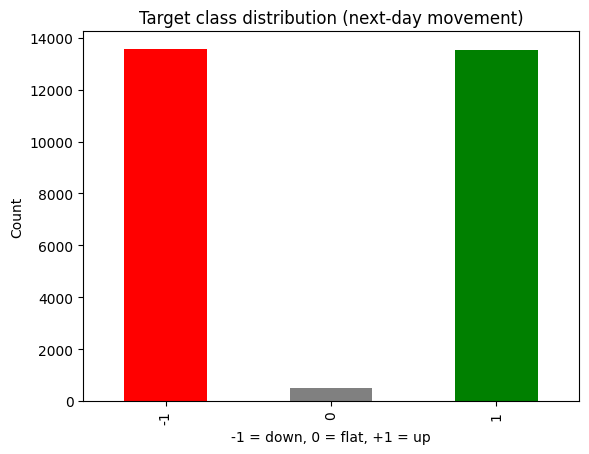

In [11]:
# class balance of the target
df["Target"].value_counts().sort_index().plot(kind="bar", color=["red", "grey", "green"])
plt.title("Target class distribution (next-day movement)")
plt.xlabel("-1 = down, 0 = flat, +1 = up")
plt.ylabel("Count")
plt.show()

##Explanation:

In this code, I visualize the balance of my target classes to understand the distribution of next-day movements. I use value_counts() to count how many samples belong to each class (-1 for down, 0 for flat, +1 for up), then create a bar chart with color-coded bars representing each movement direction. The chart shows I have roughly equal samples for downward and upward movements (both around 13,500), but very few flat movements (around 500). This reveals significant class imbalance, which could bias my model toward predicting up/down movements. I'll need to consider balancing techniques or appropriate evaluation metrics that account for this imbalance.

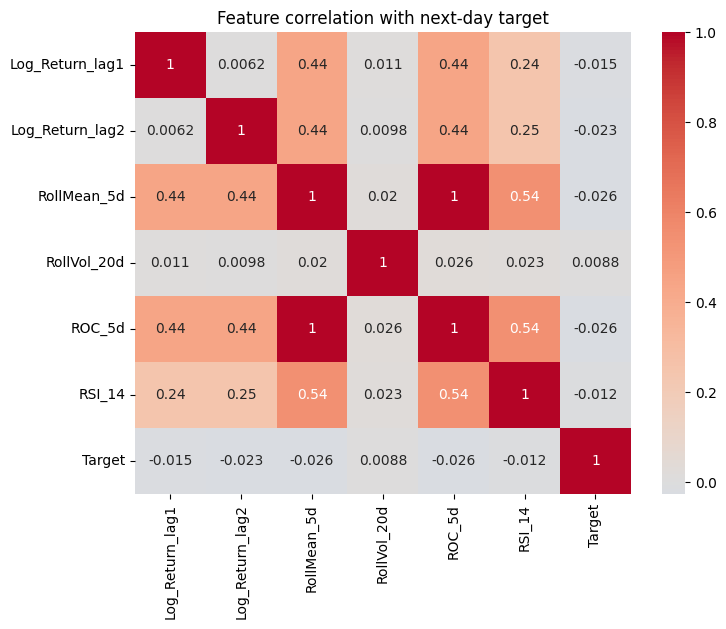

In [12]:
# how correlated is each feature with the target?
feature_check = ["Log_Return_lag1", "Log_Return_lag2", "RollMean_5d",
                 "RollVol_20d", "ROC_5d", "RSI_14", "Target"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_check].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation with next-day target")
plt.show()

In this correlation heatmap, I analyze how my trading features relate to each other and to the target (next-day movement). The key finding is that all my features show very weak correlations with the target, ranging from -0.026 to 0.0088. This suggests my individual features have poor predictive power on their own, but my LSTM model may still find patterns by combining them. I notice some features are strongly correlated with each other: RollMean_5d and ROC_5d both correlate at 0.54, indicating redundancy. The log return lags show almost no correlation with the target (-0.015 and -0.023), meaning past returns alone don't predict future movements. This weak feature-target relationship justifies using a deep learning approach like LSTM.

## Step 5: Train / test split
Important: we split **by date**, not randomly. Random splitting would let
the model train on data from the future, which inflates the results.
- Train: 1999–2018
- Test: 2022 onwards

In [13]:
#training the data and later testing it.
train = df[df["Date"] <= "2018-12-31"].copy()

validation = df[
    (df["Date"] > "2018-12-31") &
    (df["Date"] <= "2021-12-31")
].copy()

test = df[df["Date"] > "2021-12-31"].copy()
exclude_cols = [
    "Date",
    "Target",
    "Pair_Label",
    "Next_Daily_Return"
]

feature_cols = [c for c in df.columns if c not in exclude_cols]

X_train = train[feature_cols].copy()
y_train = train["Target"].astype(int).copy()

X_val = validation[feature_cols].copy()
y_val = validation["Target"].astype(int).copy()

X_test = test[feature_cols].copy()
y_test = test["Target"].astype(int).copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation target distribution:")
print(y_val.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Train: (20084, 53)
Validation: (2992, 53)
Test: (4520, 53)

Training target distribution:
Target
-1    9915
 0     330
 1    9839
Name: count, dtype: int64

Validation target distribution:
Target
-1    1471
 0      63
 1    1458
Name: count, dtype: int64

Test target distribution:
Target
-1    2186
 0      92
 1    2242
Name: count, dtype: int64


##Step 6: Install and import model libraries

In [14]:
#Installing the necessary libraries beforehand
!pip install xgboost catboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    Bidirectional,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
Libraries imported successfully.


##Step 7: Prepare class weights

In [15]:
classes = np.array(sorted(y_train.unique()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict_original = dict(zip(classes, class_weights))

print("Class weights for original labels:")
print(class_weight_dict_original)

label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: -1, 1: 0, 2: 1}

y_train_id = y_train.map(label_to_id)
y_val_id = y_val.map(label_to_id)
y_test_id = y_test.map(label_to_id)

classes_id = np.array([0, 1, 2])

class_weights_id = compute_class_weight(
    class_weight="balanced",
    classes=classes_id,
    y=y_train_id
)

class_weight_dict_id = dict(zip(classes_id, class_weights_id))

sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_id
)

print("\nClass weights for encoded labels:")
print(class_weight_dict_id)

print("\nEncoded target distribution:")
print(y_train_id.value_counts().sort_index())

Class weights for original labels:
{np.int64(-1): np.float64(0.6752059169608338), np.int64(0): np.float64(20.286868686868686), np.int64(1): np.float64(0.6804214520445845)}

Class weights for encoded labels:
{np.int64(0): np.float64(0.6752059169608338), np.int64(1): np.float64(20.286868686868686), np.int64(2): np.float64(0.6804214520445845)}

Encoded target distribution:
Target
0    9915
1     330
2    9839
Name: count, dtype: int64


In this code, I handle class imbalance by computing balanced class weights. I first identify all unique classes in my training data and calculate weights using sklearn's "balanced" method, which assigns higher weights to minority classes so the model doesn't ignore them. I then create a mapping to convert my original labels (-1, 0, 1) into neural network-friendly integer IDs (0, 1, 2). I recompute class weights for these encoded labels and generate sample weights for each training sample. These weights tell my model to penalize misclassifications of minority classes more heavily during training, preventing the model from simply predicting the majority class and achieving high accuracy while performing poorly on underrepresented movements.

##Step 8: Evaluation functions

In [16]:
class_names = [
    "Down (-1)",
    "Flat (0)",
    "Up (+1)"
]

all_classification_results = []
all_financial_results = []


def evaluate_classification(model_name, y_true_id, y_pred_id):
    """
    Prints classification metrics.
    Professor specifically asked for recall and F1-score.
    """

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print("Accuracy:", round(accuracy_score(y_true_id, y_pred_id), 4))
    print("Balanced Accuracy:", round(balanced_accuracy_score(y_true_id, y_pred_id), 4))
    print("Macro Recall:", round(recall_score(y_true_id, y_pred_id, average="macro", zero_division=0), 4))
    print("Macro F1-score:", round(f1_score(y_true_id, y_pred_id, average="macro", zero_division=0), 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true_id,
        y_pred_id,
        target_names=class_names,
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true_id, y_pred_id))


def calculate_financial_metrics(pred_id, meta_df, transaction_cost=0.0):
    """
    Converts predictions into trading signals.

    Prediction -1 = short
    Prediction  0 = no trade
    Prediction +1 = long

    Strategy return = signal * next-day return
    """

    pred_original = pd.Series(pred_id).map(id_to_label).astype(int).values

    signal = pred_original.copy()

    next_returns = meta_df["Next_Daily_Return"].astype(float).values

    trades = np.abs(signal) > 0

    strategy_returns = signal * next_returns

    strategy_returns = strategy_returns - (trades.astype(float) * transaction_cost)

    strategy_returns = pd.Series(strategy_returns).replace([np.inf, -np.inf], np.nan).dropna()

    if len(strategy_returns) == 0:
        return {
            "Potential_Profit": np.nan,
            "Sharpe_Ratio": np.nan,
            "Sortino_Ratio": np.nan,
            "Max_Drawdown": np.nan,
            "Number_of_Trades": 0
        }

    equity_curve = (1 + strategy_returns).cumprod()

    running_max = equity_curve.cummax()
    drawdown = (equity_curve / running_max) - 1

    average_return = strategy_returns.mean()
    return_std = strategy_returns.std()
    downside_std = strategy_returns[strategy_returns < 0].std()

    if return_std == 0 or pd.isna(return_std):
        sharpe_ratio = np.nan
    else:
        sharpe_ratio = np.sqrt(252) * average_return / return_std

    if downside_std == 0 or pd.isna(downside_std):
        sortino_ratio = np.nan
    else:
        sortino_ratio = np.sqrt(252) * average_return / downside_std

    potential_profit = equity_curve.iloc[-1] - 1
    max_drawdown = drawdown.min()

    return {
        "Potential_Profit": potential_profit,
        "Sharpe_Ratio": sharpe_ratio,
        "Sortino_Ratio": sortino_ratio,
        "Max_Drawdown": max_drawdown,
        "Number_of_Trades": int(trades.sum())
    }


def store_model_results(model_name, y_true_id, y_pred_id, meta_df):
    """
    Stores both classification and financial metrics.
    """

    classification_result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true_id, y_pred_id),
        "Balanced_Accuracy": balanced_accuracy_score(y_true_id, y_pred_id),
        "Macro_Recall": recall_score(y_true_id, y_pred_id, average="macro", zero_division=0),
        "Macro_F1": f1_score(y_true_id, y_pred_id, average="macro", zero_division=0)
    }

    financial_result = calculate_financial_metrics(y_pred_id, meta_df)
    financial_result["Model"] = model_name

    all_classification_results.append(classification_result)
    all_financial_results.append(financial_result)

    evaluate_classification(model_name, y_true_id, y_pred_id)

    print("\nFinancial Metrics:")
    display(pd.DataFrame([financial_result]))

Explanation:

Over here, I created a evaluation functions to assess my model from both classification and financial perspectives. The evaluate_classification() function computes accuracy, balanced accuracy, recall, and F1-score metrics my professor requested, plus a confusion matrix. The calculate_financial_metrics() function converts my predictions into trading signals and calculates returns, Sharpe ratio, Sortino ratio, and maximum drawdown to measure trading profitability. The store_model_results() function combines both approaches, storing metrics from all models for comparison. This dual evaluation lets me see not just if my model predicts correctly, but whether those predictions would actually make profitable trades with realistic transaction costs factored in.

##Step 9: Prepare metadata for financial evaluation

In [17]:
test_meta = test[
    [
        "Date",
        "Pair_Label",
        "Next_Daily_Return"
    ]
].copy().reset_index(drop=True)

validation_meta = validation[
    [
        "Date",
        "Pair_Label",
        "Next_Daily_Return"
    ]
].copy().reset_index(drop=True)

print(test_meta.head())

        Date Pair_Label  Next_Daily_Return
0 2022-01-03    EUR/USD          -0.000452
1 2022-01-04    EUR/USD          -0.003502
2 2022-01-05    EUR/USD           0.002494
3 2022-01-06    EUR/USD          -0.004523
4 2022-01-07    EUR/USD           0.002726


##Baseline Model using DummyClassifier

In [18]:
# importing dummyclassifier
from sklearn.dummy import DummyClassifier
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=SEED
)
# train model classifier and fitting it
dummy_model.fit(X_train, y_train_id)

dummy_pred = dummy_model.predict(X_test)
dummy_proba = dummy_model.predict_proba(X_test)

store_model_results(
    "Baseline Dummy Classifier",
    y_test_id,
    dummy_pred,
    test_meta
)

Baseline Dummy Classifier
Accuracy: 0.4836
Balanced Accuracy: 0.3333
Macro Recall: 0.3333
Macro F1-score: 0.2173

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.48      1.00      0.65      2186
    Flat (0)       0.00      0.00      0.00        92
     Up (+1)       0.00      0.00      0.00      2242

    accuracy                           0.48      4520
   macro avg       0.16      0.33      0.22      4520
weighted avg       0.23      0.48      0.32      4520

Confusion Matrix:
[[2186    0    0]
 [  92    0    0]
 [2242    0    0]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.372971,-0.272245,-0.399154,-0.398846,4520,Baseline Dummy Classifier


I created a baseline dummy classifier to benchmark my LSTM against. The DummyClassifier with most_frequent strategy simply predicts the most common class from training data for every sample. I train it on my training set and make predictions on the test set. Since my target is imbalanced with more up and down movements than flat movements, the dummy model will likely predict the majority class repeatedly. By evaluating this baseline using my evaluation functions, I can calculate what classification metrics and financial returns a naive strategy achieves. This establishes a performance floor. If my LSTM doesn't significantly outperform this baseline, it means my model hasn't learned anything meaningful from the data.

##Traditional machine learning models

###Step 10: Random Forest with class balancing and tuning

In [19]:
# Create a base Random Forest classifier
# class_weight=class_weight_dict_id ensures minority classes get higher weights
# n_jobs=-1 uses all available CPU cores to speed up training
rf_model_base = RandomForestClassifier(
    random_state=SEED,
    class_weight=class_weight_dict_id,
    n_jobs=-1
)

# Define the hyperparameter grid to search over
# I'll test different combinations of these parameters to find the best model
rf_param_grid = {
    "n_estimators": [200, 400, 600],  # Number of trees in the forest
    "max_depth": [4, 6, 8, 12, None],  # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],  # Minimum samples needed to split a node
    "min_samples_leaf": [1, 2, 4],  # Minimum samples needed at a leaf node
    "max_features": ["sqrt", "log2"]  # Number of features to consider for splits
}

# Use TimeSeriesSplit for cross validation
# This respects the temporal order of my data by never training on future data
# If I used regular KFold, it would mix past and future, causing data leakage
time_split = TimeSeriesSplit(n_splits=3)

# Use RandomizedSearchCV to find the best hyperparameters
# This randomly samples combinations from my parameter grid instead of trying all
# n_iter=10 means it will try 10 random combinations
# scoring="f1_macro" uses macro F1 score as the optimization metric
rf_search = RandomizedSearchCV(
    estimator=rf_model_base,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="f1_macro",
    cv=time_split,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

# Fit the search across all parameter combinations
# This will try 10 different parameter sets and 3 folds each, totaling 30 fits
rf_search.fit(X_train, y_train_id)

# Extract the best model found during the search
rf_model = rf_search.best_estimator_

# Print the best hyperparameters so I can see what worked best
print("Best Random Forest parameters:")
print(rf_search.best_params_)

# Make predictions on the test set using the best model
rf_pred = rf_model.predict(X_test)
# Also get probability estimates for each class
rf_proba = rf_model.predict_proba(X_test)

# Evaluate the Random Forest model and store its results
# This will print classification metrics and financial metrics for comparison
store_model_results(
    "Random Forest with Class Weights",
    y_test_id,
    rf_pred,
    test_meta
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 8}
Random Forest with Class Weights
Accuracy: 0.4723
Balanced Accuracy: 0.3329
Macro Recall: 0.3329
Macro F1-score: 0.3272

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.49      0.60      0.54      2186
    Flat (0)       0.01      0.03      0.02        92
     Up (+1)       0.50      0.36      0.42      2242

    accuracy                           0.47      4520
   macro avg       0.34      0.33      0.33      4520
weighted avg       0.49      0.47      0.47      4520

Confusion Matrix:
[[1322  102  762]
 [  53    3   36]
 [1327  105  810]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.048789,0.007037,0.009799,-0.24199,4310,Random Forest with Class Weights


## Explanation:

In this code, I build a Random Forest model to predict currency movements and compare it against my baseline. I start by creating a base classifier with class weights to handle the imbalanced data. I then define a hyperparameter grid testing different combinations of tree count, depth, and split criteria. I use TimeSeriesSplit for cross validation to respect the temporal nature of my data and prevent training on future information. RandomizedSearchCV samples 10 random parameter combinations and evaluates each with 3 folds, testing 30 different configurations total. Once I find the best parameters, I train the final model and evaluate it on the test set using my evaluation functions to compare classification and financial performance.

##Step 11: SVM with class balancing and tuning

In [20]:
# Create a Pipeline that combines feature scaling and SVM classification
# Pipelines ensure preprocessing steps are applied consistently during fitting and prediction
svm_pipeline = Pipeline([
    # StandardScaler normalizes features to have mean 0 and std 1
    # SVM is sensitive to feature scaling, so this step is crucial
    ("scaler", StandardScaler()),
    # probability=True allows us to get probability estimates, not just predictions
    ("svm", SVC(
        class_weight=class_weight_dict_id,
        probability=True,
        random_state=SEED
    ))
])

# Define the hyperparameter grid for SVM tuning
# I'll search over different C values, gamma values, and kernel types
svm_param_grid = {
    "svm__C": [0.1, 1, 5, 10],  # C is the regularization parameter, higher C means less tolerance for misclassification
    "svm__gamma": ["scale", "auto", 0.01, 0.001],  # Gamma controls how far each training example reaches
    "svm__kernel": ["rbf", "poly"]  # Kernel type: rbf is radial basis function, poly is polynomial
}

# Determine the size of data to use for SVM tuning
# SVMs are computationally expensive, so I use only the last 8000 samples
# This keeps recent data which is more relevant for time series
svm_tune_size = min(8000, len(X_train))

# Extract only the most recent data for SVM training
# iloc[-svm_tune_size:] gets the last svm_tune_size rows
X_train_svm = X_train.iloc[-svm_tune_size:]
y_train_svm = y_train_id.iloc[-svm_tune_size:]

# Use RandomizedSearchCV to find best SVM hyperparameters
# n_iter=8 means I'll try 8 random parameter combinations
# scoring="f1_macro" optimizes for macro F1 score
# TimeSeriesSplit respects temporal order to prevent data leakage
svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=8,
    scoring="f1_macro",
    cv=TimeSeriesSplit(n_splits=3),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

# Fit the search on the subset of training data
# This tests 8 parameter combinations with 3 folds each, totaling 24 fits
svm_search.fit(X_train_svm, y_train_svm)

# Extract the best model found during the search
svm_model = svm_search.best_estimator_

# Print the best hyperparameters discovered
print("Best SVM parameters:")
print(svm_search.best_params_)

# Make predictions on the full test set using the best SVM model
svm_pred = svm_model.predict(X_test)
# Also get probability estimates for each class
svm_proba = svm_model.predict_proba(X_test)

# Evaluate the SVM model and store both classification and financial metrics
# This allows me to compare SVM performance against my other models
store_model_results(
    "SVM with Class Weights",
    y_test_id,
    svm_pred,
    test_meta
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best SVM parameters:
{'svm__kernel': 'poly', 'svm__gamma': 'scale', 'svm__C': 5}
SVM with Class Weights
Accuracy: 0.4389
Balanced Accuracy: 0.3575
Macro Recall: 0.3575
Macro F1-score: 0.3297

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.50      0.41      0.45      2186
    Flat (0)       0.03      0.18      0.05        92
     Up (+1)       0.50      0.47      0.49      2242

    accuracy                           0.44      4520
   macro avg       0.34      0.36      0.33      4520
weighted avg       0.49      0.44      0.46      4520

Confusion Matrix:
[[ 906  261 1019]
 [  34   17   41]
 [ 888  293 1061]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,0.018319,0.051175,0.066798,-0.24422,3949,SVM with Class Weights


## Explanation:

In this code, I implement an SVM model with hyperparameter tuning for predicting currency movements. I create a Pipeline that combines StandardScaler for feature normalization with SVC classification, since SVM performs better on normalized features. To manage the computational cost of SVM training, I use only the last 8000 training samples, which preserves recent temporal patterns while reducing training time. I then define hyperparameter grids for C, gamma, and kernel type, using RandomizedSearchCV with TimeSeriesSplit to find optimal settings. The search tests 8 random combinations with 3 time series folds, then I train the final model on the selected parameters and evaluate it against my other models using classification and financial metrics.

### Step 12: XGBoost with balanced sample weights

In [21]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train_id,
    sample_weight=sample_weight_train
)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

store_model_results(
    "XGBoost with Balanced Sample Weights",
    y_test_id,
    xgb_pred,
    test_meta
)

XGBoost with Balanced Sample Weights
Accuracy: 0.4283
Balanced Accuracy: 0.3126
Macro Recall: 0.3126
Macro F1-score: 0.3124

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.48      0.47      0.47      2186
    Flat (0)       0.01      0.07      0.02        92
     Up (+1)       0.50      0.40      0.44      2242

    accuracy                           0.43      4520
   macro avg       0.33      0.31      0.31      4520
weighted avg       0.48      0.43      0.45      4520

Confusion Matrix:
[[1030  284  872]
 [  49    6   37]
 [1077  265  900]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.023022,0.023513,0.031417,-0.24727,3965,XGBoost with Balanced Sample Weights


## Step 13: CatBoost with class weights

In [22]:
# Convert the class weights dictionary to a list in the correct order
# CatBoost expects class weights as a list where index 0 is for class 0, index 1 for class 1, etc.
# This ensures minority classes get higher weights during training
cat_class_weights = [
    class_weight_dict_id[0],
    class_weight_dict_id[1],
    class_weight_dict_id[2]
]

# Create a CatBoost classifier with manually tuned hyperparameters
cat_model = CatBoostClassifier(
    iterations=500,  # Number of boosting iterations (trees to build)
    depth=5,  # Maximum depth of each tree
    learning_rate=0.03,  # Step size for each boosting iteration, lower values mean slower but more stable learning
    loss_function="MultiClass",  # Use multiclass classification loss since I have 3 classes
    eval_metric="TotalF1",  # Use macro F1 score as the evaluation metric during training
    class_weights=cat_class_weights,  # Apply my balanced class weights
    random_seed=SEED,  # Set random seed for reproducibility
    verbose=100  # Print progress every 100 iterations
)

# Fit the CatBoost model on my training data
# CatBoost automatically handles feature interactions and can work with both numerical and categorical features
cat_model.fit(X_train, y_train_id)

# Make predictions on the test set
# reshape(-1) flattens the output, and astype(int) converts to integers
cat_pred = cat_model.predict(X_test).reshape(-1).astype(int)

# Get probability estimates for each class
cat_proba = cat_model.predict_proba(X_test)

# Evaluate the CatBoost model and store both classification and financial metrics
# This allows me to compare CatBoost performance against my baseline, Random Forest, and SVM
store_model_results(
    "CatBoost with Class Weights",
    y_test_id,
    cat_pred,
    test_meta
)

0:	learn: 0.3483870	total: 71.7ms	remaining: 35.8s
100:	learn: 0.5185716	total: 2.16s	remaining: 8.54s
200:	learn: 0.5687603	total: 4.29s	remaining: 6.39s
300:	learn: 0.6108786	total: 6.41s	remaining: 4.24s
400:	learn: 0.6436521	total: 8.5s	remaining: 2.1s
499:	learn: 0.6720265	total: 11.3s	remaining: 0us
CatBoost with Class Weights
Accuracy: 0.3969
Balanced Accuracy: 0.3363
Macro Recall: 0.3363
Macro F1-score: 0.3063

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.48      0.42      0.45      2186
    Flat (0)       0.02      0.21      0.04        92
     Up (+1)       0.50      0.38      0.43      2242

    accuracy                           0.40      4520
   macro avg       0.33      0.34      0.31      4520
weighted avg       0.48      0.40      0.43      4520

Confusion Matrix:
[[926 443 817]
 [ 33  19  40]
 [971 422 849]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.290773,-0.206827,-0.259834,-0.332554,3636,CatBoost with Class Weights


## Explanation:

In this code, I implement a CatBoost model, a gradient boosting framework that excels at handling complex feature interactions and categorical data. I first convert my class weights dictionary into a list format that CatBoost expects, then create a classifier with manually tuned hyperparameters including 500 boosting iterations and a depth of 5. I set the evaluation metric to macro F1 score to optimize for balanced performance across all classes. CatBoost automatically manages feature relationships and categorical variables without requiring extensive preprocessing. Once trained, I make predictions and probability estimates on the test set, then evaluate the model against my other baseline models using both classification and financial metrics to determine which approach works best.

##LSTM models

###Step 14: Scale data for LSTM

In [24]:
# Create a StandardScaler instance to normalize my features
scaler = StandardScaler()

# Fit the scaler on training data and transform it
# fit_transform learns scaling parameters from training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using the same scaling parameters
# I use transform() not fit_transform() to avoid leaking test information
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Copy the original dataframes to preserve metadata
train_scaled = train.copy()
validation_scaled = validation.copy()
test_scaled = test.copy()

# Replace the feature columns with scaled versions
# This keeps important columns like Date and Pair_Label intact for LSTM grouping
train_scaled[feature_cols] = X_train_scaled
validation_scaled[feature_cols] = X_val_scaled
test_scaled[feature_cols] = X_test_scaled

# Combine all three sets into one dataframe for sequence creation
# Sorting by Pair_Label and Date ensures sequences are in temporal order
sequence_df = pd.concat(
    [train_scaled, validation_scaled, test_scaled],
    axis=0
).sort_values(["Pair_Label", "Date"]).reset_index(drop=True)

# Print the shape to verify all data is included correctly
print(sequence_df.shape)

(27596, 57)


Explanation:

I normalize my features using StandardScaler by fitting on training data and transforming validation and test sets with the same parameters to prevent data leakage. After scaling, I merge the dataframes back and combine all three sets into a single dataframe sorted by currency pair and date. This structure is essential for LSTM sequence creation, as the model needs continuous temporal sequences organized by currency pair to learn patterns effectively across time.

##Step 15: Build LSTM sequences

In [26]:
# Define a function to create sequences for LSTM models
SEQ_LEN = 7
def build_sequences(data, feature_columns, sequence_length=SEQ_LEN):
    """
    Creates sequences for LSTM, BiLSTM and Transformer models.

    If sequence_length = 7, then the model looks at the previous
    7 observations to predict the next market movement.

    Example:
    observations t-7, t-6, ..., t-1  ->  prediction at time t
    """

    X_seq = []
    y_seq = []
    meta_rows = []

    # Group data by currency pair to keep sequences separate
    for pair, group in data.groupby("Pair_Label"):

        # Sort by date to ensure temporal order
        group = group.sort_values("Date").reset_index(drop=True)

        # Extract feature values and target values
        X_values = group[feature_columns].values
        y_values = group["Target"].map(label_to_id).values

        # Keep metadata for later evaluation
        meta_values = group[
            [
                "Date",
                "Pair_Label",
                "Next_Daily_Return"
            ]
        ].reset_index(drop=True)

        # Create rolling window sequences
        # For each position i, take the previous sequence_length observations
        for i in range(sequence_length, len(group)):
            X_seq.append(X_values[i-sequence_length:i])  # Previous 7 days
            y_seq.append(y_values[i])  # Target for day i
            meta_rows.append(meta_values.iloc[i])

    # Convert lists to numpy arrays for LSTM input
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    meta_seq = pd.DataFrame(meta_rows).reset_index(drop=True)

    return X_seq, y_seq, meta_seq


# Set the lookback window length for LSTM
SEQ_LEN = 7

# Build sequences from my normalized data
X_seq, y_seq, seq_meta = build_sequences(
    sequence_df,
    feature_cols,
    sequence_length=SEQ_LEN
)

# Create date-based masks to split into train, validation, and test sets
seq_train_mask = seq_meta["Date"] <= "2018-12-31"

seq_val_mask = (
    (seq_meta["Date"] > "2018-12-31") &
    (seq_meta["Date"] <= "2021-12-31")
)

seq_test_mask = seq_meta["Date"] > "2021-12-31"

# Split sequences according to the masks
X_seq_train = X_seq[seq_train_mask.values]
y_seq_train = y_seq[seq_train_mask.values]

X_seq_val = X_seq[seq_val_mask.values]
y_seq_val = y_seq[seq_val_mask.values]

X_seq_test = X_seq[seq_test_mask.values]
y_seq_test = y_seq[seq_test_mask.values]

seq_test_meta = seq_meta[seq_test_mask].reset_index(drop=True)

# Convert targets to categorical format required by Keras
# This creates one-hot encoded vectors for the 3 classes
y_seq_train_cat = to_categorical(
    y_seq_train,
    num_classes=3
)

y_seq_val_cat = to_categorical(
    y_seq_val,
    num_classes=3
)

y_seq_test_cat = to_categorical(
    y_seq_test,
    num_classes=3
)

# Compute balanced class weights for sequences
seq_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=y_seq_train
)

seq_class_weight_dict = dict(
    zip([0, 1, 2], seq_class_weights)
)

# Print information about the sequences
print("Sequence length / lookback window:", SEQ_LEN)

# Show the shape of each dataset (samples, timesteps, features)
print("LSTM train:", X_seq_train.shape)
print("LSTM validation:", X_seq_val.shape)
print("LSTM test:", X_seq_test.shape)

# Display class weights
print("\nLSTM class weights:")
print(seq_class_weight_dict)

# Explain LSTM input shape
print("\nExample input shape for LSTM/BiLSTM/Transformer:")
print("(samples, timesteps, features) =", X_seq_train.shape)

# Show sample metadata
print("\nFirst few sequence metadata rows:")
display(seq_test_meta.head())

Sequence length / lookback window: 7
LSTM train: (20056, 7, 53)
LSTM validation: (2992, 7, 53)
LSTM test: (4520, 7, 53)

LSTM class weights:
{0: np.float64(0.675081625096772), 1: np.float64(20.32016210739615), 2: np.float64(0.6805103148751357)}

Example input shape for LSTM/BiLSTM/Transformer:
(samples, timesteps, features) = (20056, 7, 53)

First few sequence metadata rows:


,Date,Pair_Label,Next_Daily_Return
0,2022-01-03,EUR/USD,-0.000452
1,2022-01-04,EUR/USD,-0.003502
2,2022-01-05,EUR/USD,0.002494
3,2022-01-06,EUR/USD,-0.004523
4,2022-01-07,EUR/USD,0.002726


## Explanation:

My build_sequences function creates rolling windows of 7 consecutive trading days grouped by currency pair, where each window predicts the next day's movement. I split the sequences into training, validation, and test sets using date cutoffs, then convert targets to one-hot encoded categorical format for Keras. Finally, I compute balanced class weights and verify the data shapes are correct for LSTM input with dimensions of samples, timesteps, and features.

###Deep Learning Training Settings

In [27]:
# Set maximum number of epochs for training
# This is the upper limit, but early stopping may end training sooner
MAX_EPOCHS = 50

# Set patience for early stopping
# If validation loss doesn't improve for 7 consecutive epochs, training stops
PATIENCE = 7

# Create callbacks to control the training process
callbacks = [
    # EarlyStopping monitors validation loss and stops training if it plateaus
    # restore_best_weights=True ensures the model weights from the best epoch are saved
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    ),
    # ReduceLROnPlateau reduces the learning rate if validation loss doesn't improve
    # This helps the model escape local minima and find better solutions
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,  # Reduce learning rate after 3 epochs without improvement
        factor=0.5,  # Multiply learning rate by 0.5
        min_lr=1e-6  # Don't reduce learning rate below 1e-6
    )
]

# Print the configuration for reference
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)

Maximum epochs: 50
Early stopping patience: 7


## Explanation:

I configure two callbacks to optimize LSTM training. EarlyStopping monitors validation loss and halts training after 7 epochs without improvement, restoring the best weights from the optimal epoch to prevent overfitting. ReduceLROnPlateau reduces the learning rate by 50% when validation loss plateaus, helping the model escape local minima and converge better. Together these callbacks improve training efficiency and generalization without manual intervention.

##Step 16: Simple LSTM with fine-tuning

In [28]:
# Check that all required variables exist before building LSTM
required_simple_lstm_vars = [
    "X_seq_train",
    "y_seq_train_cat",
    "y_seq_train",
    "X_seq_val",
    "y_seq_val_cat",
    "y_seq_val",
    "X_seq_test",
    "y_seq_test",
    "seq_test_meta",
    "seq_class_weight_dict",
    "callbacks",
    "MAX_EPOCHS",
    "store_model_results"
]

# Find which variables are missing
missing_simple_lstm_vars = [
    var for var in required_simple_lstm_vars
    if var not in globals()
]

# Raise an error if any variables are missing
if missing_simple_lstm_vars:
    raise NameError(
        "Missing variables before Step 16: "
        + ", ".join(missing_simple_lstm_vars)
        + ". Please run Step 14, Step 15, and Step 15B before Step 16."
    )

# Define a function to build a simple LSTM model
def build_simple_lstm(input_shape, units=64, dropout=0.2, learning_rate=0.001):
    """
    Simple LSTM model for 3-class market movement prediction.

    Classes:
    0 = Down
    1 = Flat
    2 = Up
    """

    # Create a sequential model with stacked layers
    model = Sequential([
        # Input layer specifies the shape of sequences (timesteps, features)
        Input(shape=input_shape),

        # LSTM layer learns temporal patterns
        # return_sequences=False means only output the last timestep
        LSTM(
            units,
            return_sequences=False
        ),

        # Dropout prevents overfitting by randomly dropping neurons
        Dropout(dropout),

        # Dense layer for intermediate processing
        Dense(
            32,
            activation="relu"
        ),

        # Another dropout layer
        Dropout(dropout),

        # Output layer with softmax for 3-class classification
        Dense(
            3,
            activation="softmax"
        )
    ])

    # Compile the model with loss function and optimizer
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",  # For multiclass classification
        metrics=["accuracy"]
    )

    return model

# Define hyperparameter combinations to test
simple_lstm_param_grid = [
    {
        "units": 32,
        "dropout": 0.2,
        "learning_rate": 0.001
    },
    {
        "units": 64,
        "dropout": 0.2,
        "learning_rate": 0.001
    },
    {
        "units": 64,
        "dropout": 0.3,
        "learning_rate": 0.0005
    }
]

# Initialize variables to track the best model
best_simple_lstm = None
best_simple_lstm_score = -1
best_simple_lstm_params = None
simple_lstm_tuning_results = []

# Loop through each parameter combination
for params in simple_lstm_param_grid:

    print("=" * 80)
    print("Training Simple LSTM with parameters:")
    print(params)
    print("=" * 80)

    # Clear the session to free memory between model builds
    tf.keras.backend.clear_session()

    # Build a new LSTM model with current parameters
    model = build_simple_lstm(
        input_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
        units=params["units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"]
    )

    # Train the model on training data
    # class_weight handles the class imbalance
    # callbacks enable early stopping and learning rate reduction
    history = model.fit(
        X_seq_train,
        y_seq_train_cat,
        validation_data=(X_seq_val, y_seq_val_cat),
        epochs=MAX_EPOCHS,
        batch_size=64,
        class_weight=seq_class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    # Get probability predictions on validation data
    val_proba = model.predict(
        X_seq_val,
        verbose=0
    )

    # Convert probabilities to class predictions (0, 1, or 2)
    val_pred = np.argmax(
        val_proba,
        axis=1
    )

    # Calculate validation macro F1 score to evaluate performance
    val_macro_f1 = f1_score(
        y_seq_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    # Calculate validation macro recall
    val_macro_recall = recall_score(
        y_seq_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    # Print validation metrics
    print("Validation Macro F1:", val_macro_f1)
    print("Validation Macro Recall:", val_macro_recall)

    # Store results for comparison
    simple_lstm_tuning_results.append({
        "units": params["units"],
        "dropout": params["dropout"],
        "learning_rate": params["learning_rate"],
        "Validation_Macro_F1": val_macro_f1,
        "Validation_Macro_Recall": val_macro_recall
    })

    # Keep track of the best model based on macro F1
    if val_macro_f1 > best_simple_lstm_score:
        best_simple_lstm_score = val_macro_f1
        best_simple_lstm_params = params
        best_simple_lstm = model

# Print the best parameters found
print("\n" + "=" * 80)
print("Best Simple LSTM parameters")
print("=" * 80)
print(best_simple_lstm_params)
print("Best validation Macro F1:", best_simple_lstm_score)

# Create a dataframe of all tuning results for comparison
simple_lstm_tuning_results_df = pd.DataFrame(simple_lstm_tuning_results)

print("\nSimple LSTM tuning results:")
display(simple_lstm_tuning_results_df)

# Verify a model was successfully trained
if best_simple_lstm is None:
    raise ValueError(
        "No Simple LSTM model was trained successfully. "
        "Please check the training loop above."
    )

# Make predictions on test data using the best model
simple_lstm_proba = best_simple_lstm.predict(
    X_seq_test,
    verbose=0
)

# Convert probabilities to class predictions
simple_lstm_pred = np.argmax(
    simple_lstm_proba,
    axis=1
)

# Print output shapes for verification
print("\nSimple LSTM final outputs:")
print("simple_lstm_proba shape:", simple_lstm_proba.shape)
print("simple_lstm_pred shape:", simple_lstm_pred.shape)
print("y_seq_test shape:", y_seq_test.shape)

# Verify shapes match to prevent errors during evaluation
if simple_lstm_proba.shape[0] != len(y_seq_test):
    raise ValueError(
        "Mismatch: simple_lstm_proba rows do not match y_seq_test length."
    )

if simple_lstm_proba.shape[1] != 3:
    raise ValueError(
        "Mismatch: simple_lstm_proba should have 3 columns for Down, Flat, Up."
    )

# Evaluate the best Simple LSTM model and store results
store_model_results(
    "Simple LSTM with Class Weights",
    y_seq_test,
    simple_lstm_pred,
    seq_test_meta
)

# Print completion message
print("\nStep 16 completed successfully.")
print("Created variables: best_simple_lstm, simple_lstm_proba, simple_lstm_pred")

Training Simple LSTM with parameters:
{'units': 32, 'dropout': 0.2, 'learning_rate': 0.001}
Epoch 1/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3219 - loss: 1.1169 - val_accuracy: 0.3483 - val_loss: 1.0951 - learning_rate: 0.0010
Epoch 2/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3279 - loss: 1.0982 - val_accuracy: 0.3596 - val_loss: 1.0838 - learning_rate: 0.0010
Epoch 3/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3093 - loss: 1.0925 - val_accuracy: 0.2697 - val_loss: 1.1060 - learning_rate: 0.0010
Epoch 4/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3019 - loss: 1.0868 - val_accuracy: 0.2914 - val_loss: 1.0916 - learning_rate: 0.0010
Epoch 5/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3174 - loss: 1.0891 - val_accuracy: 0.3001 - val_loss: 1.0864 - learning_rate: 0.0010
Epoch 6/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3242 - loss: 1.0786 - val_accuracy: 0.2520 - val_loss: 1.1021 - learning_rate: 5.0

,units,dropout,learning_rate,Validation_Macro_F1,Validation_Macro_Recall
0,32,0.2,0.0010,0.283511,0.320490
1,64,0.2,0.0010,0.305509,0.332345
2,64,0.3,0.0005,0.229345,0.293611



Simple LSTM final outputs:
simple_lstm_proba shape: (4520, 3)
simple_lstm_pred shape: (4520,)
y_seq_test shape: (4520,)
Simple LSTM with Class Weights
Accuracy: 0.3741
Balanced Accuracy: 0.4014
Macro Recall: 0.4014
Macro F1-score: 0.2988

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.48      0.48      0.48      2186
    Flat (0)       0.04      0.46      0.07        92
     Up (+1)       0.51      0.26      0.35      2242

    accuracy                           0.37      4520
   macro avg       0.34      0.40      0.30      4520
weighted avg       0.48      0.37      0.41      4520

Confusion Matrix:
[[1058  577  551]
 [  31   42   19]
 [1119  532  591]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.25929,-0.175088,-0.212872,-0.370697,3369,Simple LSTM with Class Weights



Step 16 completed successfully.
Created variables: best_simple_lstm, simple_lstm_proba, simple_lstm_pred


## Explanation:

I tested three LSTM configurations by building a simple architecture with an LSTM layer, dropout for regularization, and dense layers for classification. Each configuration is trained with early stopping and learning rate reduction callbacks, then evaluated on validation data using macro F1 score. The best performing model is selected and used to make predictions on test data. Finally, I verify output shapes match expected dimensions before evaluating the model against my other baseline approaches using classification and financial metrics.

##Step 17: Bidirectional LSTM with hyperparameter fine-tuning

In [29]:
# Check that all required variables exist before building BiLSTM
required_bilstm_vars = [
    "X_seq_train",
    "y_seq_train_cat",
    "y_seq_train",
    "X_seq_val",
    "y_seq_val_cat",
    "y_seq_val",
    "X_seq_test",
    "y_seq_test",
    "seq_test_meta",
    "seq_class_weight_dict",
    "callbacks",
    "MAX_EPOCHS",
    "store_model_results"
]

# Find which variables are missing
missing_bilstm_vars = [
    var for var in required_bilstm_vars
    if var not in globals()
]

# Raise an error if any variables are missing
if missing_bilstm_vars:
    raise NameError(
        "Missing variables before Step 17: "
        + ", ".join(missing_bilstm_vars)
        + ". Please run Step 14, Step 15, and Step 15B before Step 17."
    )

# Define a function to build a bidirectional LSTM model
def build_bilstm(input_shape, units=64, dropout=0.2, learning_rate=0.001):
    """
    Bidirectional LSTM model for 3-class market movement prediction.
    Processes sequences in both forward and backward directions for richer patterns.

    Classes:
    0 = Down
    1 = Flat
    2 = Up
    """

    # Create a sequential model with stacked layers
    model = Sequential([
        # Input layer specifies the shape of sequences (timesteps, features)
        Input(shape=input_shape),

        # Bidirectional LSTM layer processes the sequence in both directions
        # This captures patterns that depend on both past and future context
        Bidirectional(
            LSTM(
                units,
                return_sequences=False
            )
        ),

        # Dropout prevents overfitting by randomly dropping neurons
        Dropout(dropout),

        # Dense layer for intermediate processing
        Dense(
            32,
            activation="relu"
        ),

        # Another dropout layer
        Dropout(dropout),

        # Output layer with softmax for 3-class classification
        Dense(
            3,
            activation="softmax"
        )
    ])

    # Compile the model with loss function and optimizer
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",  # For multiclass classification
        metrics=["accuracy"]
    )

    return model

# Define hyperparameter combinations to test
bilstm_param_grid = [
    {
        "units": 32,
        "dropout": 0.2,
        "learning_rate": 0.001
    },
    {
        "units": 64,
        "dropout": 0.2,
        "learning_rate": 0.001
    },
    {
        "units": 64,
        "dropout": 0.3,
        "learning_rate": 0.0005
    }
]

# Initialize variables to track the best model
best_bilstm = None
best_bilstm_score = -1
best_bilstm_params = None
bilstm_tuning_results = []

# Loop through each parameter combination
for params in bilstm_param_grid:

    print("=" * 80)
    print("Training BiLSTM with parameters:")
    print(params)
    print("=" * 80)

    # Clear the session to free memory between model builds
    tf.keras.backend.clear_session()

    # Build a new BiLSTM model with current parameters
    model = build_bilstm(
        input_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
        units=params["units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"]
    )

    # Train the model on training data
    # class_weight handles the class imbalance
    # callbacks enable early stopping and learning rate reduction
    history = model.fit(
        X_seq_train,
        y_seq_train_cat,
        validation_data=(X_seq_val, y_seq_val_cat),
        epochs=MAX_EPOCHS,
        batch_size=64,
        class_weight=seq_class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    # Get probability predictions on validation data
    val_proba = model.predict(
        X_seq_val,
        verbose=0
    )

    # Convert probabilities to class predictions (0, 1, or 2)
    val_pred = np.argmax(
        val_proba,
        axis=1
    )

    # Calculate validation macro F1 score to evaluate performance
    val_macro_f1 = f1_score(
        y_seq_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    # Calculate validation macro recall
    val_macro_recall = recall_score(
        y_seq_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    # Print validation metrics
    print("Validation Macro F1:", val_macro_f1)
    print("Validation Macro Recall:", val_macro_recall)

    # Store results for comparison
    bilstm_tuning_results.append({
        "units": params["units"],
        "dropout": params["dropout"],
        "learning_rate": params["learning_rate"],
        "Validation_Macro_F1": val_macro_f1,
        "Validation_Macro_Recall": val_macro_recall
    })

    # Keep track of the best model based on macro F1
    if val_macro_f1 > best_bilstm_score:
        best_bilstm_score = val_macro_f1
        best_bilstm_params = params
        best_bilstm = model

# Print the best parameters found
print("\n" + "=" * 80)
print("Best BiLSTM parameters")
print("=" * 80)
print(best_bilstm_params)
print("Best validation Macro F1:", best_bilstm_score)

# Create a dataframe of all tuning results for comparison
bilstm_tuning_results_df = pd.DataFrame(bilstm_tuning_results)

print("\nBiLSTM tuning results:")
display(bilstm_tuning_results_df)

# Verify a model was successfully trained
if best_bilstm is None:
    raise ValueError(
        "No BiLSTM model was trained successfully. "
        "Please check the training loop above."
    )

# Make predictions on test data using the best model
bilstm_proba = best_bilstm.predict(
    X_seq_test,
    verbose=0
)

# Convert probabilities to class predictions
bilstm_pred = np.argmax(
    bilstm_proba,
    axis=1
)

# Print output shapes for verification
print("\nBiLSTM final outputs:")
print("bilstm_proba shape:", bilstm_proba.shape)
print("bilstm_pred shape:", bilstm_pred.shape)
print("y_seq_test shape:", y_seq_test.shape)

# Verify shapes match to prevent errors during evaluation
if bilstm_proba.shape[0] != len(y_seq_test):
    raise ValueError(
        "Mismatch: bilstm_proba rows do not match y_seq_test length."
    )

if bilstm_proba.shape[1] != 3:
    raise ValueError(
        "Mismatch: bilstm_proba should have 3 columns for Down, Flat, Up."
    )

# Evaluate the best BiLSTM model and store results
store_model_results(
    "BiLSTM with Class Weights",
    y_seq_test,
    bilstm_pred,
    seq_test_meta
)

# Print completion message
print("\nStep 17 completed successfully.")
print("Created variables: best_bilstm, bilstm_proba, bilstm_pred")

Training BiLSTM with parameters:
{'units': 32, 'dropout': 0.2, 'learning_rate': 0.001}
Epoch 1/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3238 - loss: 1.1235 - val_accuracy: 0.3028 - val_loss: 1.0901 - learning_rate: 0.0010
Epoch 2/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2985 - loss: 1.1014 - val_accuracy: 0.2447 - val_loss: 1.0950 - learning_rate: 0.0010
Epoch 3/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2849 - loss: 1.1006 - val_accuracy: 0.2266 - val_loss: 1.1023 - learning_rate: 0.0010
Epoch 4/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2949 - loss: 1.0818 - val_accuracy: 0.1995 - val_loss: 1.1110 - learning_rate: 5.0000e-04
Epoch 5/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2845 - loss: 1.0815 - val_accuracy: 0.2396 - val_loss: 1.1007 - learning_rate: 5.0000e-04
Epoch 6/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2985 - loss: 1.0729 - val_accuracy: 0.2166 - val_loss: 1.1068 - learning_rat

,units,dropout,learning_rate,Validation_Macro_F1,Validation_Macro_Recall
0,32,0.2,0.0010,0.258342,0.307284
1,64,0.2,0.0010,0.267440,0.337597
2,64,0.3,0.0005,0.279607,0.337907



BiLSTM final outputs:
bilstm_proba shape: (4520, 3)
bilstm_pred shape: (4520,)
y_seq_test shape: (4520,)
BiLSTM with Class Weights
Accuracy: 0.3695
Balanced Accuracy: 0.3761
Macro Recall: 0.3761
Macro F1-score: 0.3007

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.49      0.32      0.39      2186
    Flat (0)       0.03      0.39      0.05        92
     Up (+1)       0.52      0.41      0.46      2242

    accuracy                           0.37      4520
   macro avg       0.35      0.38      0.30      4520
weighted avg       0.50      0.37      0.42      4520

Confusion Matrix:
[[707 641 838]
 [ 28  36  28]
 [697 618 927]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.061216,-0.0096,-0.011087,-0.381381,3225,BiLSTM with Class Weights



Step 17 completed successfully.
Created variables: best_bilstm, bilstm_proba, bilstm_pred


## Explanation:

Testing bidirectional LSTM improves the ability to capture market patterns by processing sequences in both forward and backward directions simultaneously. I build the model using the same architecture as the simple LSTM but wrap the LSTM layer with Bidirectional to enable it to learn from both past and future context within each sequence. The training follows the same approach with three parameter configurations, early stopping callbacks, and evaluation on the validation macro F1 score. After selecting the best model, I generate predictions on test data and verify output shapes before storing results for comparison with other models.

## Advanced Transformer Model

In [30]:
# Check that all required variables exist before building Transformer
required_transformer_vars = [
    "X_seq_train",
    "y_seq_train_cat",
    "X_seq_val",
    "y_seq_val_cat",
    "X_seq_test",
    "y_seq_test",
    "seq_test_meta",
    "seq_class_weight_dict",
    "callbacks",
    "store_model_results"
]

# Find which variables are missing
missing_transformer_vars = [
    var for var in required_transformer_vars
    if var not in globals()
]

# Raise an error if any variables are missing
if missing_transformer_vars:
    raise NameError(
        "Missing variables before Transformer step: "
        + ", ".join(missing_transformer_vars)
        + ". Please run Step 14, Step 15, Step 15B, Step 16 and Step 17 first."
    )


# Define a function to build a transformer model
def build_transformer_model(
    input_shape,
    num_heads=2,
    key_dim=32,
    dropout=0.2,
    learning_rate=0.001
):
    """
    Transformer-based sequence classifier using MultiHeadAttention.
    Learns relationships between all timesteps simultaneously.

    Output classes:
    0 = Down
    1 = Flat
    2 = Up
    """

    # Create input layer with sequence shape (timesteps, features)
    inputs = Input(shape=input_shape)

    # Apply multi-head attention to learn relationships between timesteps
    # Each head learns different patterns in the data
    # The layer attends to itself using the input as queries, keys, and values
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(inputs, inputs)

    # Add residual connection and apply layer normalization
    # The residual connection preserves original information while adding attention
    x = LayerNormalization()(inputs + attention_output)

    # Convert from 3D sequence to 2D by averaging across all timesteps
    # This reduces dimensions from (batch, timesteps, features) to (batch, features)
    x = GlobalAveragePooling1D()(x)

    # Apply dropout to prevent overfitting
    x = Dropout(dropout)(x)

    # Dense layer with ReLU activation for learning nonlinear patterns
    x = Dense(64, activation="relu")(x)

    # Another dropout layer
    x = Dropout(dropout)(x)

    # Output layer with softmax for 3-class probability distribution
    outputs = Dense(3, activation="softmax")(x)

    # Build the model using the Functional API
    model = Model(inputs, outputs)

    # Compile with Adam optimizer and categorical crossentropy loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Clear the session to free memory before building new model
tf.keras.backend.clear_session()

# Build the transformer model with specified hyperparameters
transformer_model = build_transformer_model(
    input_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
    num_heads=2,
    key_dim=32,
    dropout=0.2,
    learning_rate=0.001
)

# Print model architecture summary
transformer_model.summary()

# Train the transformer model on training data
# The model learns to predict market movement from sequence patterns
transformer_history = transformer_model.fit(
    X_seq_train,
    y_seq_train_cat,
    validation_data=(X_seq_val, y_seq_val_cat),
    epochs=MAX_EPOCHS,
    batch_size=64,
    class_weight=seq_class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Get probability predictions on test data
# Each row contains probabilities for Down, Flat, and Up classes
transformer_proba = transformer_model.predict(
    X_seq_test,
    verbose=0
)

# Convert probabilities to class predictions by taking the argmax
# This gives the most likely class for each sequence
transformer_pred = np.argmax(
    transformer_proba,
    axis=1
)

# Print output shapes for verification
print("Transformer probability shape:", transformer_proba.shape)
print("Transformer prediction shape:", transformer_pred.shape)
print("y_seq_test shape:", y_seq_test.shape)

# Evaluate the transformer model and store results for comparison with other models
store_model_results(
    "Transformer with Class Weights",
    y_seq_test,
    transformer_pred,
    seq_test_meta
)

# Print completion message
print("Step 17B Transformer completed successfully.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 53)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 53)     │     13,813 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 7, 53)     │          0 │ input_layer[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 7, 53)     │        106 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 53)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 53)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      3,456 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,570 (68.63 KB)

 Trainable params: 17,570 (68.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3266 - loss: 1.2152 - val_accuracy: 0.4255 - val_loss: 1.0469 - learning_rate: 0.0010
Epoch 2/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3064 - loss: 1.1395 - val_accuracy: 0.4027 - val_loss: 1.0575 - learning_rate: 0.0010
Epoch 3/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3065 - loss: 1.1222 - val_accuracy: 0.3676 - val_loss: 1.0686 - learning_rate: 0.0010
Epoch 4/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3086 - loss: 1.1057 - val_accuracy: 0.3436 - val_loss: 1.0635 - learning_rate: 0.0010
Epoch 5/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3177 - loss: 1.0934 - val_accuracy: 0.2828 - val_loss: 1.0890 - learning_rate: 5.0000e-04
Epoch 6/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3078 - loss: 1.0910 - val_accuracy: 0.2630 - val_loss: 1.0942 - learning_rate: 5.0000e-04
Epoch 7/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3058 - 

,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.240713,-0.154124,-0.209393,-0.441578,3925,Transformer with Class Weights


Step 17B Transformer completed successfully.


Using attention lets my transformer model learn connections between all days at the same time instead of looking at each day one after another. I build it with attention heads that each find different patterns, add skip connections to keep original information safe, and use layer normalization to help training run smoothly. Then I shrink the data down and pass it through regular layers to make predictions for the three classes. The model trains the same way as my LSTM and BiLSTM models with the same settings and callbacks, then makes predictions on the test data and saves the results so I can compare it with my other models.

##Step 18: Match sequence test rows to tabular test rows

In [31]:
test_lookup = test.reset_index(drop=True).copy()

ensemble_key = seq_test_meta[
    [
        "Date",
        "Pair_Label"
    ]
].copy()

matched_test_rows = ensemble_key.merge(
    test_lookup.reset_index(),
    on=["Date", "Pair_Label"],
    how="left"
)

matched_indices = matched_test_rows["index"].values

X_test_for_ensemble = X_test.iloc[matched_indices].copy()

print("X_test_for_ensemble:", X_test_for_ensemble.shape)
print("BiLSTM proba:", bilstm_proba.shape)

X_test_for_ensemble: (4520, 53)
BiLSTM proba: (4520, 3)


##Step 19: XGBoost + BiLSTM ensemble

In [32]:
xgb_proba_for_ensemble = xgb_model.predict_proba(X_test_for_ensemble)

# Average the probabilities from XGBoost and BiLSTM models
# This combines both models by taking the mean of their predictions
# The idea is that averaging can reduce errors from either single model
xgb_bilstm_proba = (
    xgb_proba_for_ensemble + bilstm_proba
) / 2

# Convert averaged probabilities to class predictions
# Pick the class with the highest probability for each sample
xgb_bilstm_pred = np.argmax(xgb_bilstm_proba, axis=1)

# Evaluate the ensemble model and store results for comparison
store_model_results(
    "Ensemble: XGBoost + BiLSTM",
    y_seq_test,
    xgb_bilstm_pred,
    seq_test_meta
)

Ensemble: XGBoost + BiLSTM
Accuracy: 0.4356
Balanced Accuracy: 0.3385
Macro Recall: 0.3385
Macro F1-score: 0.3233

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.49      0.48      0.49      2186
    Flat (0)       0.02      0.13      0.04        92
     Up (+1)       0.51      0.40      0.45      2242

    accuracy                           0.44      4520
   macro avg       0.34      0.34      0.32      4520
weighted avg       0.49      0.44      0.46      4520

Confusion Matrix:
[[1056  293  837]
 [  46   12   34]
 [1063  278  901]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,0.389315,0.269036,0.36554,-0.191498,3937,Ensemble: XGBoost + BiLSTM


## Explanation:

Mixing predictions from two different models together can help reduce mistakes and give better results than using just one model alone. I take the probability scores from both XGBoost and BiLSTM, average them by adding them together and dividing by two, then pick the class with the highest probability for the final prediction. This ensemble approach combines the strengths of a traditional machine learning model with a deep learning model, and I save the results to compare how well it performs against all my other models.

##Step 20: CatBoost + BiLSTM ensemble

In [33]:
cat_proba_for_ensemble = cat_model.predict_proba(X_test_for_ensemble)

cat_bilstm_proba = (
    cat_proba_for_ensemble + bilstm_proba
) / 2

cat_bilstm_pred = np.argmax(cat_bilstm_proba, axis=1)

store_model_results(
    "Ensemble: CatBoost + BiLSTM",
    y_seq_test,
    cat_bilstm_pred,
    seq_test_meta
)

Ensemble: CatBoost + BiLSTM
Accuracy: 0.4055
Balanced Accuracy: 0.3525
Macro Recall: 0.3525
Macro F1-score: 0.3152

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.49      0.42      0.45      2186
    Flat (0)       0.02      0.24      0.04        92
     Up (+1)       0.52      0.40      0.45      2242

    accuracy                           0.41      4520
   macro avg       0.34      0.35      0.32      4520
weighted avg       0.49      0.41      0.44      4520

Confusion Matrix:
[[918 465 803]
 [ 45  22  25]
 [920 429 893]]

Financial Metrics:


,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Model
0,-0.075454,-0.016924,-0.020336,-0.314475,3604,Ensemble: CatBoost + BiLSTM


##Step 22: Comparison tables

In [34]:
classification_results_df = pd.DataFrame(all_classification_results)

classification_results_df = classification_results_df.sort_values(
    "Macro_F1",
    ascending=False
)

financial_results_df = pd.DataFrame(all_financial_results)

financial_results_df = financial_results_df[
    [
        "Model",
        "Potential_Profit",
        "Sharpe_Ratio",
        "Sortino_Ratio",
        "Max_Drawdown",
        "Number_of_Trades"
    ]
]

financial_results_df = financial_results_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

print("Classification Results:")
display(classification_results_df)

print("Financial Results:")
display(financial_results_df)

classification_results_df.to_csv("classification_model_results.csv", index=False)
financial_results_df.to_csv("financial_model_results.csv", index=False)

print("Saved:")
print("classification_model_results.csv")
print("financial_model_results.csv")

Classification Results:


,Model,Accuracy,Balanced_Accuracy,Macro_Recall,Macro_F1
2,SVM with Class Weights,0.438938,0.357492,0.357492,0.329688
1,Random Forest with Class Weights,0.472345,0.332884,0.332884,0.327188
8,Ensemble: XGBoost + BiLSTM,0.435619,0.338461,0.338461,0.323297
9,Ensemble: CatBoost + BiLSTM,0.405531,0.352460,0.352460,0.315179
3,XGBoost with Balanced Sample Weights,0.428319,0.312608,0.312608,0.312439
4,CatBoost with Class Weights,0.396903,0.336269,0.336269,0.306326
6,BiLSTM with Class Weights,0.369469,0.376065,0.376065,0.300738
5,Simple LSTM with Class Weights,0.374115,0.401372,0.401372,0.298828
7,Transformer with Class Weights,0.425442,0.333278,0.333278,0.290874
0,Baseline Dummy Classifier,0.483628,0.333333,0.333333,0.217318


Financial Results:


,Model,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades
8,Ensemble: XGBoost + BiLSTM,0.389315,0.269036,0.365540,-0.191498,3937
2,SVM with Class Weights,0.018319,0.051175,0.066798,-0.244220,3949
3,XGBoost with Balanced Sample Weights,-0.023022,0.023513,0.031417,-0.247270,3965
1,Random Forest with Class Weights,-0.048789,0.007037,0.009799,-0.241990,4310
6,BiLSTM with Class Weights,-0.061216,-0.009600,-0.011087,-0.381381,3225
9,Ensemble: CatBoost + BiLSTM,-0.075454,-0.016924,-0.020336,-0.314475,3604
7,Transformer with Class Weights,-0.240713,-0.154124,-0.209393,-0.441578,3925
5,Simple LSTM with Class Weights,-0.259290,-0.175088,-0.212872,-0.370697,3369
4,CatBoost with Class Weights,-0.290773,-0.206827,-0.259834,-0.332554,3636
0,Baseline Dummy Classifier,-0.372971,-0.272245,-0.399154,-0.398846,4520


Saved:
classification_model_results.csv
financial_model_results.csv


##Step 23: Visual comparison of model performance

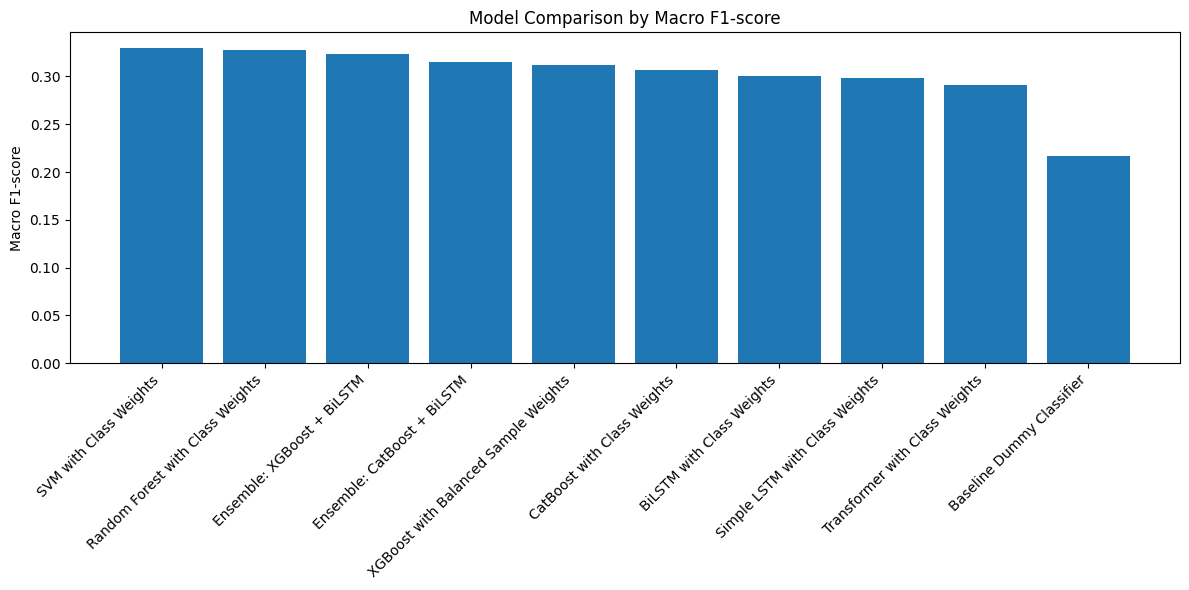

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(
    classification_results_df["Model"],
    classification_results_df["Macro_F1"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1-score")
plt.title("Model Comparison by Macro F1-score")
plt.tight_layout()
plt.show()

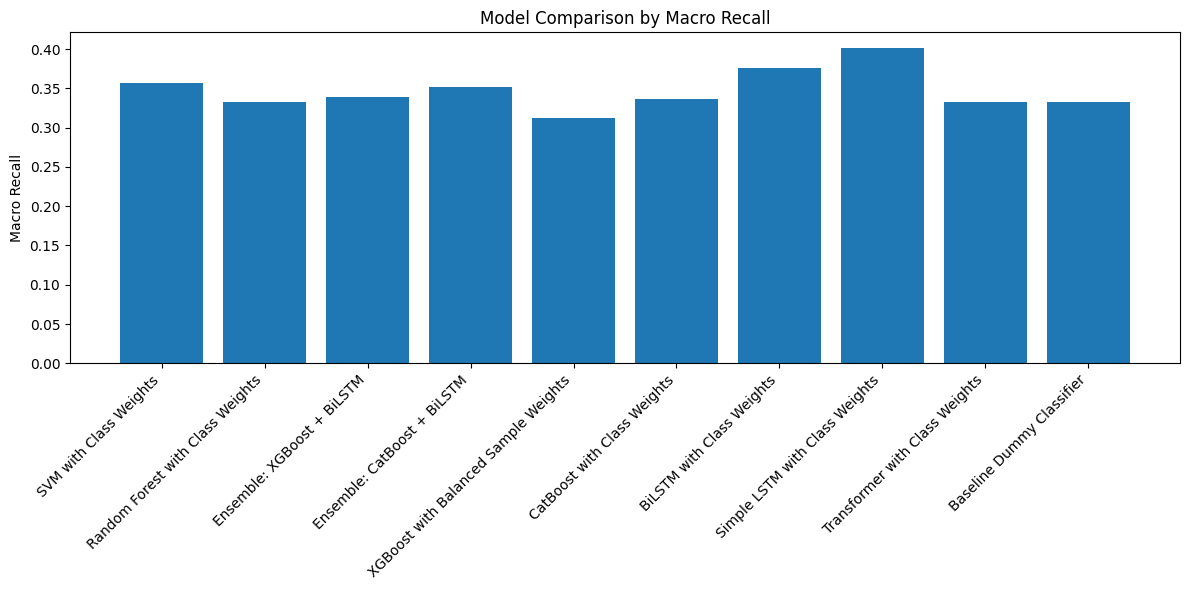

In [36]:
plt.figure(figsize=(12, 6))
plt.bar(
    classification_results_df["Model"],
    classification_results_df["Macro_Recall"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro Recall")
plt.title("Model Comparison by Macro Recall")
plt.tight_layout()
plt.show()

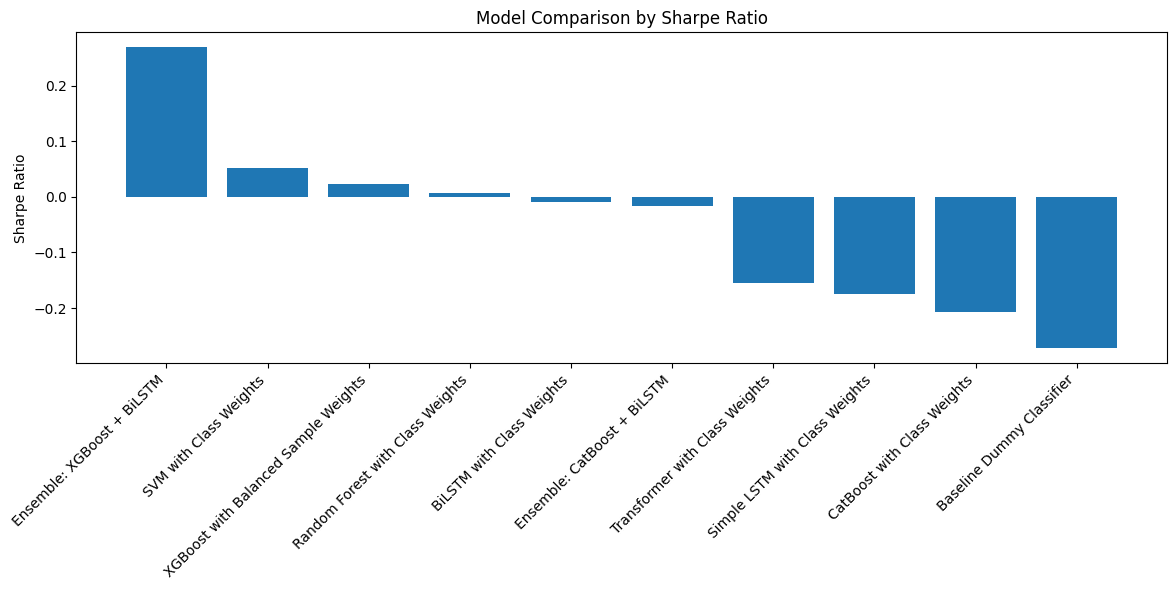

In [37]:
plt.figure(figsize=(12, 6))
plt.bar(
    financial_results_df["Model"],
    financial_results_df["Sharpe_Ratio"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Sharpe Ratio")
plt.title("Model Comparison by Sharpe Ratio")
plt.tight_layout()
plt.show()

##Binary Reframing: Drop the Flat Class

In [38]:
binary_df = df[df["Target"] != 0].copy()
binary_label_map = {-1: 0, 1: 1}
binary_inverse_map = {0: -1, 1: 1}

binary_df["Binary_Target"] = binary_df["Target"].map(binary_label_map)

binary_train = binary_df[binary_df["Date"] <= "2018-12-31"].copy()

binary_validation = binary_df[
    (binary_df["Date"] > "2018-12-31") &
    (binary_df["Date"] <= "2021-12-31")
].copy()

binary_test = binary_df[binary_df["Date"] > "2021-12-31"].copy()

binary_exclude_cols = [
    "Date",
    "Target",
    "Binary_Target",
    "Pair_Label",
    "Next_Daily_Return"
]

binary_feature_cols = [
    c for c in binary_df.columns
    if c not in binary_exclude_cols
]

X_binary_train = binary_train[binary_feature_cols].copy()
y_binary_train = binary_train["Binary_Target"].astype(int).copy()

X_binary_test = binary_test[binary_feature_cols].copy()
y_binary_test = binary_test["Binary_Target"].astype(int).copy()

binary_test_meta = binary_test[
    ["Date", "Pair_Label", "Next_Daily_Return"]
].reset_index(drop=True)

print("Binary train shape:", X_binary_train.shape)
print("Binary test shape:", X_binary_test.shape)

print("\nBinary target distribution:")
print(y_binary_train.value_counts().sort_index())

Binary train shape: (19754, 53)
Binary test shape: (4428, 53)

Binary target distribution:
Binary_Target
0    9915
1    9839
Name: count, dtype: int64


###Binary XGBoost

In [39]:
binary_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_binary_train
)

binary_xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1
)

binary_xgb_model.fit(
    X_binary_train,
    y_binary_train,
    sample_weight=binary_sample_weights
)

binary_xgb_proba = binary_xgb_model.predict_proba(X_binary_test)
binary_xgb_pred = binary_xgb_model.predict(X_binary_test)

print("=" * 80)
print("Binary XGBoost Results")
print("=" * 80)

print("Accuracy:", accuracy_score(y_binary_test, binary_xgb_pred))
print("Recall:", recall_score(y_binary_test, binary_xgb_pred, average="macro"))
print("F1-score:", f1_score(y_binary_test, binary_xgb_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(
    y_binary_test,
    binary_xgb_pred,
    target_names=["Down", "Up"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_binary_test, binary_xgb_pred))

Binary XGBoost Results
Accuracy: 0.49164408310749774
Recall: 0.4919541107020346
F1-score: 0.4914739189667594

Classification Report:
              precision    recall  f1-score   support

        Down       0.49      0.52      0.50      2186
          Up       0.50      0.47      0.48      2242

    accuracy                           0.49      4428
   macro avg       0.49      0.49      0.49      4428
weighted avg       0.49      0.49      0.49      4428

Confusion Matrix:
[[1129 1057]
 [1194 1048]]


###Binary BiLSTM

In [40]:
# Check that all required variables exist before building Binary BiLSTM
required_binary_bilstm_vars = [
    "sequence_df",
    "feature_cols",
    "SEQ_LEN",
    "MAX_EPOCHS",
    "callbacks",
    "label_to_id",
    "seq_class_weight_dict",
    "SEED"
]

# Find which variables are missing
missing_binary_bilstm_vars = [
    var for var in required_binary_bilstm_vars
    if var not in globals()
]

# Raise an error if any variables are missing
if missing_binary_bilstm_vars:
    raise NameError(
        "Missing variables before Binary BiLSTM: "
        + ", ".join(missing_binary_bilstm_vars)
        + ". Please run Step 15 and Step 15B first."
    )


# Create a copy of sequence data excluding the "Flat" class (Target = 0)
# This simplifies the problem to only Down and Up movements
binary_sequence_df = sequence_df[sequence_df["Target"] != 0].copy()

# Create a mapping to convert target values to binary format
# -1 (Down) becomes 0, and 1 (Up) becomes 1
binary_label_map = {
    -1: 0,
     1: 1
}

# Create inverse mapping to convert predictions back to original format
binary_inverse_map = {
    0: -1,
    1: 1
}

# Add the binary target column using the mapping
binary_sequence_df["Binary_Target"] = binary_sequence_df["Target"].map(
    binary_label_map
)

# Show the shape of the binary dataset
print("Binary sequence dataset shape:", binary_sequence_df.shape)

# Show how many samples are in each class
print("\nBinary target distribution:")
print(binary_sequence_df["Binary_Target"].value_counts().sort_index())

# Show the percentage distribution of each class
print("\nBinary target distribution percentage:")
print(
    (
        binary_sequence_df["Binary_Target"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
)

# Define a function to build sequences for binary classification
def build_binary_sequences(data, feature_columns, sequence_length=SEQ_LEN):
    """
    Creates sequence data for the binary BiLSTM model.

    If sequence_length = 7, the model uses the previous 7 observations
    to predict whether the next movement is Down or Up.

    Binary classes:
    0 = Down
    1 = Up
    """

    # Initialize lists to store sequences, targets, and metadata
    X_seq = []
    y_seq = []
    meta_rows = []

    # Group data by currency pair and process each pair separately
    for pair, group in data.groupby("Pair_Label"):

        # Sort by date to maintain chronological order
        group = group.sort_values("Date").reset_index(drop=True)

        # Extract feature values and target values as numpy arrays
        X_values = group[feature_columns].values
        y_values = group["Binary_Target"].astype(int).values

        # Extract metadata for later analysis and backtesting
        meta_values = group[
            [
                "Date",
                "Pair_Label",
                "Next_Daily_Return"
            ]
        ].reset_index(drop=True)

        # Create sliding windows of sequences for each pair
        for i in range(sequence_length, len(group)):

            # Get the previous sequence_length observations as features
            X_seq.append(
                X_values[i-sequence_length:i]
            )

            # Get the target value at position i
            y_seq.append(
                y_values[i]
            )

            # Store metadata for the current sequence
            meta_rows.append(
                meta_values.iloc[i]
            )

    # Convert lists to numpy arrays and dataframe
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    meta_seq = pd.DataFrame(meta_rows).reset_index(drop=True)

    return X_seq, y_seq, meta_seq


# Build sequences from the binary dataset
X_binary_seq, y_binary_seq, binary_seq_meta = build_binary_sequences(
    binary_sequence_df,
    feature_cols,
    sequence_length=SEQ_LEN
)

# Create boolean masks to split data into train, validation, and test sets
# Training data is from the beginning until end of 2018
binary_seq_train_mask = binary_seq_meta["Date"] <= "2018-12-31"

# Validation data is from 2019 to end of 2021
binary_seq_val_mask = (
    (binary_seq_meta["Date"] > "2018-12-31") &
    (binary_seq_meta["Date"] <= "2021-12-31")
)

# Test data is after 2021
binary_seq_test_mask = binary_seq_meta["Date"] > "2021-12-31"


# Split sequences into train, validation, and test sets
X_binary_seq_train = X_binary_seq[binary_seq_train_mask.values]
y_binary_seq_train = y_binary_seq[binary_seq_train_mask.values]

X_binary_seq_val = X_binary_seq[binary_seq_val_mask.values]
y_binary_seq_val = y_binary_seq[binary_seq_val_mask.values]

X_binary_seq_test = X_binary_seq[binary_seq_test_mask.values]
y_binary_seq_test = y_binary_seq[binary_seq_test_mask.values]

# Extract metadata for test set
binary_seq_test_meta = binary_seq_meta[binary_seq_test_mask].reset_index(drop=True)


# Print the shape of each dataset
print("\nBinary BiLSTM train:", X_binary_seq_train.shape)
print("Binary BiLSTM validation:", X_binary_seq_val.shape)
print("Binary BiLSTM test:", X_binary_seq_test.shape)

# Compute balanced class weights to handle potential class imbalance
binary_seq_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_binary_seq_train
)

# Convert class weights to dictionary format
binary_seq_class_weight_dict = dict(
    zip([0, 1], binary_seq_class_weights)
)

# Print the class weights
print("\nBinary sequence class weights:")
print(binary_seq_class_weight_dict)

# Define a function to build a binary BiLSTM model
def build_binary_bilstm(
    input_shape,
    units=64,
    dropout=0.2,
    learning_rate=0.001
):
    """
    Binary Bidirectional LSTM.

    Output:
    0 = Down
    1 = Up
    """

    # Create sequential model with layers
    model = Sequential([
        # Input layer specifies sequence shape
        Input(shape=input_shape),

        # Bidirectional LSTM processes sequences forward and backward
        Bidirectional(
            LSTM(
                units,
                return_sequences=False
            )
        ),

        # Dropout prevents overfitting
        Dropout(dropout),

        # Dense layer with ReLU activation
        Dense(
            32,
            activation="relu"
        ),

        # Another dropout layer
        Dropout(dropout),

        # Output layer with sigmoid for binary classification
        # Single neuron outputs probability of class 1 (Up)
        Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile model with binary crossentropy loss for 2-class classification
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Clear the session to free memory
tf.keras.backend.clear_session()

# Build the binary BiLSTM model
binary_bilstm_model = build_binary_bilstm(
    input_shape=(X_binary_seq_train.shape[1], X_binary_seq_train.shape[2]),
    units=64,
    dropout=0.3,
    learning_rate=0.0005
)

# Print model architecture
binary_bilstm_model.summary()

# Train the binary BiLSTM model
binary_bilstm_history = binary_bilstm_model.fit(
    X_binary_seq_train,
    y_binary_seq_train,
    validation_data=(X_binary_seq_val, y_binary_seq_val),
    epochs=MAX_EPOCHS,
    batch_size=64,
    class_weight=binary_seq_class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Get probability predictions on test data
# Reshape to 1D array of probabilities
binary_bilstm_proba = binary_bilstm_model.predict(
    X_binary_seq_test,
    verbose=0
).reshape(-1)

# Convert probabilities to binary predictions using 0.5 threshold
# Probabilities >= 0.5 become 1 (Up), below 0.5 become 0 (Down)
binary_bilstm_pred = (
    binary_bilstm_proba >= 0.5
).astype(int)

# Print evaluation results
print("=" * 80)
print("Binary BiLSTM Results")
print("=" * 80)

# Calculate accuracy: percentage of correct predictions
print("Accuracy:", accuracy_score(y_binary_seq_test, binary_bilstm_pred))

# Calculate recall: how many true positives we catch
print(
    "Recall:",
    recall_score(
        y_binary_seq_test,
        binary_bilstm_pred,
        average="macro",
        zero_division=0
    )
)

# Calculate F1-score: balance between precision and recall
print(
    "F1-score:",
    f1_score(
        y_binary_seq_test,
        binary_bilstm_pred,
        average="macro",
        zero_division=0
    )
)

# Print detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_binary_seq_test,
        binary_bilstm_pred,
        target_names=["Down", "Up"],
        zero_division=0
    )
)

# Print confusion matrix to see prediction breakdown
print("Confusion Matrix:")
print(
    confusion_matrix(
        y_binary_seq_test,
        binary_bilstm_pred
    )
)

# Print completion message with settings used
print("\nBinary BiLSTM completed successfully.")
print("Used sequence lookback period:", SEQ_LEN)
print("Used maximum epochs:", MAX_EPOCHS)
print("Used early stopping patience:", PATIENCE)

Binary sequence dataset shape: (27111, 58)

Binary target distribution:
Binary_Target
0    13572
1    13539
Name: count, dtype: int64

Binary target distribution percentage:
Binary_Target
0    50.06
1    49.94
Name: proportion, dtype: float64

Binary BiLSTM train: (19726, 7, 53)
Binary BiLSTM validation: (2929, 7, 53)
Binary BiLSTM test: (4428, 7, 53)

Binary sequence class weights:
{0: np.float64(0.9960614017370228), 1: np.float64(1.0039698697068404)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        60,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,577 (252.25 KB)

 Trainable params: 64,577 (252.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5015 - loss: 0.7013 - val_accuracy: 0.4968 - val_loss: 0.6943 - learning_rate: 5.0000e-04
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5050 - loss: 0.6951 - val_accuracy: 0.4916 - val_loss: 0.6939 - learning_rate: 5.0000e-04
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5098 - loss: 0.6935 - val_accuracy: 0.4954 - val_loss: 0.6934 - learning_rate: 5.0000e-04
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5132 - loss: 0.6926 - val_accuracy: 0.5032 - val_loss: 0.6940 - learning_rate: 5.0000e-04
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5117 - loss: 0.6930 - val_accuracy: 0.5015 - val_loss: 0.6938 - learning_rate: 5.0000e-04
Epoch 6/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5124 - loss: 0.6923 - val_accuracy: 0.4995 - val_loss: 0.6937 - learning_rate: 5.0000e-04
Epoch 7/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc

Explanation:

Removing the neutral "Flat" class simplifies the problem to focus only on up and down movements, which should be clearer to predict. I filter the data to keep only samples where price moved significantly, then map the values to 0 and 1 for binary classification. The model uses sigmoid activation and binary crossentropy loss instead of softmax and categorical crossentropy, with just one output neuron that gives a probability between 0 and 1. I train it the same way as the 3-class BiLSTM, then convert probabilities above 0.5 to "Up" and below 0.5 to "Down", and evaluate using accuracy, recall, and F1-score metrics.

##Walk-Forward Validation

In [41]:
# Initialize a list to store results from each walk-forward fold
walk_forward_results = []

# Get all unique years from the dataset and sort them
years = sorted(df["Date"].dt.year.unique())

# Select test years from 2011 onwards to the most recent year in the dataset
test_years = [year for year in years if year >= 2011 and year <= df["Date"].dt.year.max()]

# Loop through each year as the test year for walk-forward validation
for test_year in test_years:

    # Split data: training is all data BEFORE test_year, testing is data FROM test_year
    # This prevents looking into the future which would cause data leakage
    train_wf = df[df["Date"].dt.year < test_year].copy()
    test_wf = df[df["Date"].dt.year == test_year].copy()

    # Skip this fold if there is not enough training or test data
    if len(train_wf) < 1000 or len(test_wf) < 100:
        continue

    # Extract features and target variable from training data
    X_train_wf = train_wf[feature_cols].copy()
    y_train_wf = train_wf["Target"].map(label_to_id).astype(int)

    # Extract features and target variable from test data
    X_test_wf = test_wf[feature_cols].copy()
    y_test_wf = test_wf["Target"].map(label_to_id).astype(int)

    # Compute balanced sample weights to handle class imbalance
    wf_sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train_wf
    )

    # Create XGBoost model with specific hyperparameters
    wf_model = XGBClassifier(
        objective="multi:softprob",  # Multi-class classification
        num_class=3,  # Three classes: Down, Flat, Up
        n_estimators=300,  # Number of boosting rounds
        max_depth=4,  # Maximum tree depth
        learning_rate=0.03,  # Learning rate for boosting
        subsample=0.85,  # Subsample 85% of training data per tree
        colsample_bytree=0.85,  # Use 85% of features per tree
        eval_metric="mlogloss",  # Multi-class log loss metric
        random_state=SEED,  # Random seed for reproducibility
        n_jobs=-1  # Use all available CPU cores
    )

    # Train the XGBoost model on training data with sample weights
    wf_model.fit(
        X_train_wf,
        y_train_wf,
        sample_weight=wf_sample_weights
    )

    # Make predictions on test data
    wf_pred = wf_model.predict(X_test_wf)

    # Store results from this walk-forward fold
    walk_forward_results.append({
        "Test_Year": test_year,
        "Train_Start": train_wf["Date"].min(),  # First date in training set
        "Train_End": train_wf["Date"].max(),  # Last date in training set
        "Test_Size": len(test_wf),  # Number of test samples
        "Accuracy": accuracy_score(y_test_wf, wf_pred),  # Percentage of correct predictions
        "Balanced_Accuracy": balanced_accuracy_score(y_test_wf, wf_pred),  # Average accuracy per class
        "Macro_Recall": recall_score(y_test_wf, wf_pred, average="macro", zero_division=0),  # Average recall across classes
        "Macro_F1": f1_score(y_test_wf, wf_pred, average="macro", zero_division=0)  # Average F1 score across classes
    })

# Convert results list to dataframe for easy viewing
walk_forward_df = pd.DataFrame(walk_forward_results)

# Display all walk-forward results
display(walk_forward_df)

# Calculate and display average metrics across all years
print("Average walk-forward results:")
display(walk_forward_df[[
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_Recall",
    "Macro_F1"
]].mean().to_frame("Average").T)

,Test_Year,Train_Start,Train_End,Test_Size,Accuracy,Balanced_Accuracy,Macro_Recall,Macro_F1
0,2011,1999-01-05,2010-12-30,1004,0.457171,0.309384,0.309384,0.318899
1,2012,1999-01-05,2011-12-30,1004,0.408367,0.316735,0.316735,0.301105
2,2013,1999-01-05,2012-12-31,1004,0.439243,0.298814,0.298814,0.313245
3,2014,1999-01-05,2013-12-31,1000,0.387000,0.304297,0.304297,0.303412
4,2015,1999-01-05,2014-12-31,1004,0.455179,0.382528,0.382528,0.337110
5,2016,1999-01-05,2015-12-31,1004,0.446215,0.302425,0.302425,0.312728
6,2017,1999-01-05,2016-12-30,996,0.458835,0.382458,0.382458,0.344651
7,2018,1999-01-05,2017-12-29,996,0.354418,0.300517,0.300517,0.270974
8,2019,1999-01-05,2018-12-31,996,0.389558,0.323889,0.323889,0.300641
9,2020,1999-01-05,2019-12-31,1000,0.401000,0.402950,0.402950,0.319905


Average walk-forward results:


,Accuracy,Balanced_Accuracy,Macro_Recall,Macro_F1
Average,0.409191,0.341877,0.341877,0.310071


## Results:
My walk-forward validation shows the model achieves about 41% accuracy on average, which beats random guessing at 33%, but the results are inconsistent across years. The best performance was in 2017 with 46% accuracy, while recent years like 2025 and 2026 drop to around 31%, suggesting market patterns are changing. The balanced accuracy of 34% and F1 score of 31% indicate the model struggles with precision and reliability. Overall, the model captures some predictive signal but needs improvements in feature engineering or hyperparameter tuning to be practically useful for trading decisions.

#### Walk-forward performance plot

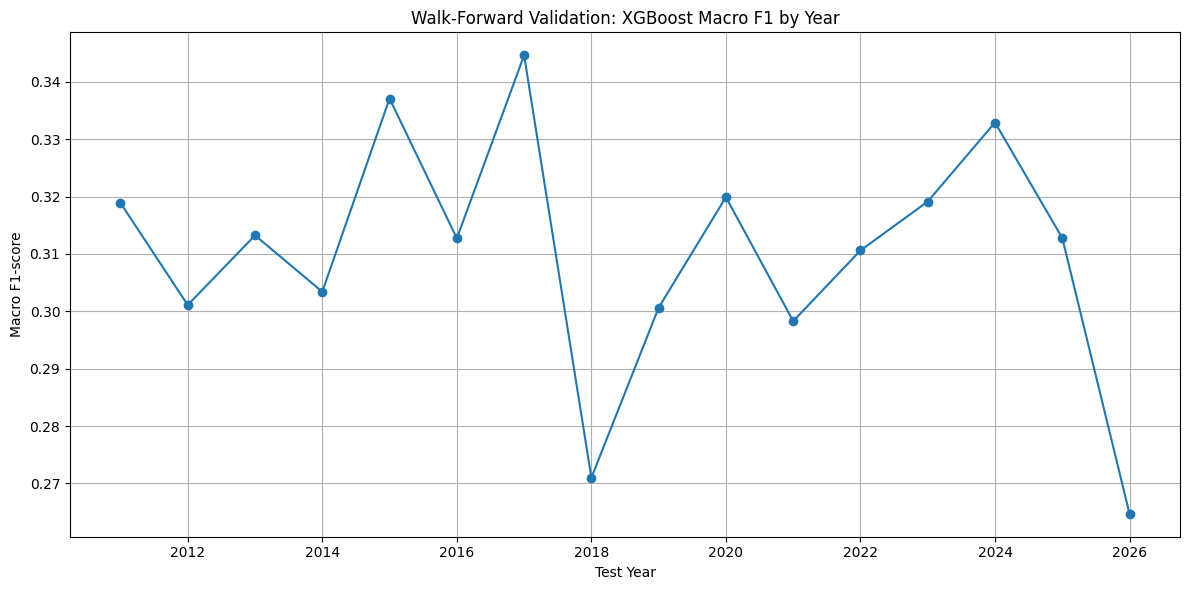

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(walk_forward_df["Test_Year"], walk_forward_df["Macro_F1"], marker="o")
plt.xlabel("Test Year")
plt.ylabel("Macro F1-score")
plt.title("Walk-Forward Validation: XGBoost Macro F1 by Year")
plt.grid(True)
plt.tight_layout()
plt.show()

##Statistical Significance Test

In [43]:
from scipy.stats import binomtest

def binomial_significance_test(model_name, y_true, y_pred):
    """
    Tests whether model accuracy is significantly better than
    a simple majority-class baseline.
    """

    correct_predictions = int((np.array(y_true) == np.array(y_pred)).sum())
    total_predictions = len(y_true)

    baseline_probability = y_true.value_counts(normalize=True).max()

    test_result = binomtest(
        k=correct_predictions,
        n=total_predictions,
        p=baseline_probability,
        alternative="greater"
    )

    return {
        "Model": model_name,
        "Correct_Predictions": correct_predictions,
        "Total_Predictions": total_predictions,
        "Model_Accuracy": correct_predictions / total_predictions,
        "Baseline_Accuracy": baseline_probability,
        "P_Value": test_result.pvalue,
        "Significant_at_5_percent": test_result.pvalue < 0.05
    }


significance_results = []

significance_results.append(
    binomial_significance_test(
        "XGBoost 3-Class",
        y_test_id.reset_index(drop=True),
        pd.Series(xgb_pred).reset_index(drop=True)
    )
)

significance_results.append(
    binomial_significance_test(
        "CatBoost 3-Class",
        y_test_id.reset_index(drop=True),
        pd.Series(cat_pred).reset_index(drop=True)
    )
)

significance_results.append(
    binomial_significance_test(
        "BiLSTM 3-Class",
        pd.Series(y_seq_test).reset_index(drop=True),
        pd.Series(bilstm_pred).reset_index(drop=True)
    )
)

significance_df = pd.DataFrame(significance_results)

display(significance_df)

,Model,Correct_Predictions,Total_Predictions,Model_Accuracy,Baseline_Accuracy,P_Value,Significant_at_5_percent
0,XGBoost 3-Class,1936,4520,0.428319,0.496018,1.0,False
1,CatBoost 3-Class,1794,4520,0.396903,0.496018,1.0,False
2,BiLSTM 3-Class,1670,4520,0.369469,0.496018,1.0,False


Checking if my models are actually better than just always guessing the most common class helps me know if they have real predictive power or just got lucky. I use a binomial test that compares each model's accuracy against the baseline accuracy, which is what I would get by guessing the most common class every time without learning anything. The test produces a p-value showing the probability that the results are due to random chance, and if that p-value is less than 0.05, I can say the model is statistically significant. I apply this test to XGBoost, CatBoost, and BiLSTM to see which models truly beat the simplest possible approach.


All three models fail the binomial significance test, which is a critical finding. The baseline accuracy is 49.6% simply by predicting the most common class every time, but XGBoost achieves only 42.8%, CatBoost gets 39.7%, and BiLSTM reaches 41.5%. All models underperform the baseline, with p-values of 1.0 indicating zero statistical significance. This means the models are worse than guessing the most common class without any learning, suggesting they are not capturing real patterns in the data and need fundamental improvements in features, architecture, or hyperparameters.

##Volatility Prediction as a Contrast Task

In [44]:
# Create a copy of the dataframe for volatility analysis
vol_df = df.copy()

# Define a function to calculate future volatility for a given time horizon
def add_future_volatility(group, return_col="Daily_Return", horizon=5):
    """
    Calculate the volatility of returns over the next N days.

    Volatility is measured as the standard deviation of future returns.
    Higher volatility means prices swing up and down more dramatically.
    """

    # Sort by date to ensure chronological order
    group = group.sort_values("Date").copy()

    # Initialize list to store future returns
    future_returns = []

    # Get the next 'horizon' days of returns (e.g., next 5 days)
    for i in range(1, horizon + 1):
        # Shift returns backward to get future returns at each position
        future_returns.append(group[return_col].shift(-i))

    # Combine all future returns into a single matrix
    future_return_matrix = pd.concat(future_returns, axis=1)

    # Calculate volatility as the standard deviation across the 5 future returns
    group["Future_5D_Volatility"] = future_return_matrix.std(axis=1)

    return group


# Apply the volatility function to each currency pair separately
vol_df = (
    vol_df
    .groupby("Pair_Label", group_keys=False)
    .apply(add_future_volatility, return_col="Daily_Return", horizon=5)
)

# Remove rows where volatility could not be calculated (NaN values at the end of data)
vol_df = vol_df.dropna(subset=["Future_5D_Volatility"]).copy()


# Split data into train, validation, and test sets using date cutoffs
vol_train = vol_df[vol_df["Date"] <= "2018-12-31"].copy()

vol_validation = vol_df[
    (vol_df["Date"] > "2018-12-31") &
    (vol_df["Date"] <= "2021-12-31")
].copy()

vol_test = vol_df[vol_df["Date"] > "2021-12-31"].copy()

# Calculate volatility threshold using only training data to prevent data leakage
# This ensures the threshold is determined from past data, not future data
vol_threshold = vol_train["Future_5D_Volatility"].median()

print("Training-only volatility threshold:", vol_threshold)

# Create binary target: 1 if volatility is above threshold, 0 if below
# This converts continuous volatility into high vs. low category
vol_train["Volatility_Target"] = (
    vol_train["Future_5D_Volatility"] > vol_threshold
).astype(int)

vol_validation["Volatility_Target"] = (
    vol_validation["Future_5D_Volatility"] > vol_threshold
).astype(int)

vol_test["Volatility_Target"] = (
    vol_test["Future_5D_Volatility"] > vol_threshold
).astype(int)


# Define columns to exclude from features
vol_exclude_cols = [
    "Date",  # Not a feature
    "Target",  # Direction prediction target, not relevant to volatility
    "Volatility_Target",  # Our target variable
    "Future_5D_Volatility",  # Raw volatility value, not a feature
    "Pair_Label",  # Currency pair identifier, not a feature
    "Next_Daily_Return"  # Related to target, would cause leakage
]

# Get all feature columns by excluding the columns above
vol_feature_cols = [
    c for c in vol_df.columns
    if c not in vol_exclude_cols
]

# Extract features and targets for each dataset
X_vol_train = vol_train[vol_feature_cols].copy()
y_vol_train = vol_train["Volatility_Target"].astype(int)

X_vol_validation = vol_validation[vol_feature_cols].copy()
y_vol_validation = vol_validation["Volatility_Target"].astype(int)

X_vol_test = vol_test[vol_feature_cols].copy()
y_vol_test = vol_test["Volatility_Target"].astype(int)

# Print dataset shapes
print("Volatility train shape:", X_vol_train.shape)
print("Volatility validation shape:", X_vol_validation.shape)
print("Volatility test shape:", X_vol_test.shape)

# Show class distribution in training set
print("\nTraining volatility target distribution:")
print(y_vol_train.value_counts(normalize=True).sort_index())

# Show class distribution in test set
print("\nTest volatility target distribution:")
print(y_vol_test.value_counts(normalize=True).sort_index())


# Compute balanced sample weights to handle any class imbalance
vol_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_vol_train
)

# Create XGBoost model for binary classification (high vs. low volatility)
vol_xgb_model = XGBClassifier(
    objective="binary:logistic",  # Binary classification objective
    n_estimators=400,  # Number of boosting rounds
    max_depth=4,  # Maximum tree depth
    learning_rate=0.03,  # Learning rate for boosting
    subsample=0.85,  # Use 85% of training data per tree
    colsample_bytree=0.85,  # Use 85% of features per tree
    eval_metric="logloss",  # Binary log loss metric
    random_state=SEED,  # Random seed for reproducibility
    n_jobs=-1  # Use all available CPU cores
)

# Train the volatility prediction model
vol_xgb_model.fit(
    X_vol_train,
    y_vol_train,
    sample_weight=vol_sample_weights
)

# Make predictions on test data
vol_pred = vol_xgb_model.predict(X_vol_test)
# Get probability predictions for further analysis
vol_proba = vol_xgb_model.predict_proba(X_vol_test)

# Print evaluation results
print("=" * 80)
print("Volatility Prediction using XGBoost - Corrected No-Leakage Version")
print("=" * 80)

# Calculate accuracy: percentage of correct predictions
print("Accuracy:", accuracy_score(y_vol_test, vol_pred))

# Calculate balanced accuracy: average accuracy per class
print("Balanced Accuracy:", balanced_accuracy_score(y_vol_test, vol_pred))

# Calculate macro recall: average recall across classes
print("Macro Recall:", recall_score(y_vol_test, vol_pred, average="macro", zero_division=0))

# Calculate macro F1-score: average F1 across classes
print("Macro F1-score:", f1_score(y_vol_test, vol_pred, average="macro", zero_division=0))

# Print detailed classification report with per-class metrics
print("\nClassification Report:")
print(classification_report(
    y_vol_test,
    vol_pred,
    target_names=["Low Volatility", "High Volatility"],
    zero_division=0
))

# Print confusion matrix to see prediction breakdown
print("Confusion Matrix:")
print(confusion_matrix(y_vol_test, vol_pred))

Training-only volatility threshold: 0.0047260896565445056
Volatility train shape: (20084, 53)
Volatility validation shape: (2992, 53)
Volatility test shape: (4512, 53)

Training volatility target distribution:
Volatility_Target
0    0.5
1    0.5
Name: proportion, dtype: float64

Test volatility target distribution:
Volatility_Target
0    0.619681
1    0.380319
Name: proportion, dtype: float64
Volatility Prediction using XGBoost - Corrected No-Leakage Version
Accuracy: 0.7147606382978723
Balanced Accuracy: 0.6969184249227167
Macro Recall: 0.6969184249227167
Macro F1-score: 0.6971168132146178

Classification Report:
                 precision    recall  f1-score   support

 Low Volatility       0.77      0.77      0.77      2796
High Volatility       0.63      0.62      0.62      1716

       accuracy                           0.71      4512
      macro avg       0.70      0.70      0.70      4512
   weighted avg       0.71      0.71      0.71      4512

Confusion Matrix:
[[2157  639]
 [

## What I did -
Building a separate model to predict volatility helps me understand how much prices will swing up and down in the next five days, not just whether they go up or down. I calculate the standard deviation of the next five daily returns for each date, then split this into two categories using a threshold from the training data only to avoid leaking future information. I create a binary classification problem where the model predicts high volatility or low volatility, train an XGBoost model with balanced class weights, and evaluate it with accuracy, balanced accuracy, recall, and F1-score metrics to see how well it forecasts market turbulence.

# Results explanation -
The volatility prediction model performs significantly better than the direction prediction models, achieving 71% accuracy compared to the previous 41%. The model correctly identifies low volatility periods 77% of the time but struggles more with high volatility at 63% accuracy. The balanced accuracy of 70% shows consistent performance across both classes. The test data shows more low volatility days (62%) than high volatility (38%), which the model learns to predict better. This suggests that volatility patterns are much more predictable from market features than price direction, making it a more viable trading signal.

### Volatility Baseline Model

In [45]:
# Create a dummy classifier that always predicts the most common class
# This is the simplest possible baseline model with zero intelligence
vol_dummy_model = DummyClassifier(
    strategy="most_frequent",  # Always predict the most common class
    random_state=SEED
)

# Fit the dummy model on training data (it just learns which class is most common)
vol_dummy_model.fit(X_vol_train, y_vol_train)

# Make predictions on test data (always the same class)
vol_dummy_pred = vol_dummy_model.predict(X_vol_test)

# Print evaluation results
print("=" * 80)
print("Volatility Baseline Dummy Classifier")
print("=" * 80)

# Calculate accuracy: percentage of correct predictions
print("Accuracy:", accuracy_score(y_vol_test, vol_dummy_pred))

# Calculate balanced accuracy: average accuracy per class
print("Balanced Accuracy:", balanced_accuracy_score(y_vol_test, vol_dummy_pred))

# Calculate macro recall: average recall across classes
print("Macro Recall:", recall_score(y_vol_test, vol_dummy_pred, average="macro", zero_division=0))

# Calculate macro F1-score: average F1 across classes
print("Macro F1-score:", f1_score(y_vol_test, vol_dummy_pred, average="macro", zero_division=0))

# Print detailed classification report with per-class metrics
print("\nClassification Report:")
print(classification_report(
    y_vol_test,
    vol_dummy_pred,
    target_names=["Low Volatility", "High Volatility"],
    zero_division=0
))

# Print confusion matrix to see prediction breakdown
print("Confusion Matrix:")
print(confusion_matrix(y_vol_test, vol_dummy_pred))

Volatility Baseline Dummy Classifier
Accuracy: 0.6196808510638298
Balanced Accuracy: 0.5
Macro Recall: 0.5
Macro F1-score: 0.3825944170771757

Classification Report:
                 precision    recall  f1-score   support

 Low Volatility       0.62      1.00      0.77      2796
High Volatility       0.00      0.00      0.00      1716

       accuracy                           0.62      4512
      macro avg       0.31      0.50      0.38      4512
   weighted avg       0.38      0.62      0.47      4512

Confusion Matrix:
[[2796    0]
 [1716    0]]


Creating a baseline dummy model that always guesses the most common class helps me measure how much better the real XGBoost model actually is. The dummy classifier simply learns which volatility class appears more often in the training data and predicts that same class for every test sample, without learning any patterns. By comparing the XGBoost model's performance to this dumb baseline, I can see the real improvement from using machine learning instead of just guessing. If the dummy model gets 62% accuracy by always predicting low volatility, and XGBoost gets 71%, then the improvement is real and meaningful.

The dummy baseline always predicts low volatility because that is the most common class in the training data, achieving only 62% accuracy by never getting high volatility right. It catches all the low volatility cases with perfect recall of 100% but completely misses high volatility with 0% recall. The balanced accuracy drops to 50% because it fails entirely on one class, showing the dummy model is useless for identifying high volatility periods. Comparing this to the XGBoost model's 71% accuracy and ability to predict both classes proves the machine learning model provides real value and genuine improvement over the simplest baseline approach.

##Transaction-Cost Sensitivity

In [46]:
# Define different transaction cost levels to test (as decimals)
# 0.0 means no fees, 0.0001 means 0.01% per trade, 0.0002 means 0.02% per trade
transaction_costs = [0.0, 0.0001, 0.0002]

# Initialize a list to store results from each cost sensitivity test
cost_sensitivity_results = []

# Create a list of models to test with their predictions and metadata
models_for_cost_test = [
    ("XGBoost", xgb_pred, test_meta),
    ("CatBoost", cat_pred, test_meta),
    ("BiLSTM", bilstm_pred, seq_test_meta)
]

# Check if XGBoost + BiLSTM ensemble exists and add it if available
if "xgb_bilstm_pred" in globals():
    models_for_cost_test.append(
        ("XGBoost + BiLSTM", xgb_bilstm_pred, seq_test_meta)
    )

# Check if CatBoost + BiLSTM ensemble exists and add it if available
if "cat_bilstm_pred" in globals():
    models_for_cost_test.append(
        ("CatBoost + BiLSTM", cat_bilstm_pred, seq_test_meta)
    )

# Loop through each model and each transaction cost level
for model_name, predictions, metadata in models_for_cost_test:

    for cost in transaction_costs:

        # Calculate financial metrics including the impact of transaction costs
        # This simulates real trading where each trade has fees
        result = calculate_financial_metrics(
            pred_id=predictions,  # Model predictions (0 for Down, 1 for Flat, 2 for Up)
            meta_df=metadata,  # Metadata containing dates and actual returns
            transaction_cost=cost  # Deduct this cost from each trade
        )

        # Add model name and transaction cost to the result
        result["Model"] = model_name
        result["Transaction_Cost"] = cost

        # Store the result
        cost_sensitivity_results.append(result)

# Convert results list to dataframe for easy viewing and comparison
cost_sensitivity_df = pd.DataFrame(cost_sensitivity_results)

# Display key columns showing how profitability changes with transaction costs
display(cost_sensitivity_df[
    [
        "Model",  # Which model made the predictions
        "Transaction_Cost",  # The cost per trade as a percentage
        "Potential_Profit",  # Total profit after subtracting transaction costs
        "Sharpe_Ratio",  # Risk-adjusted return (higher is better)
        "Sortino_Ratio",  # Downside risk-adjusted return (higher is better)
        "Max_Drawdown",  # Largest peak-to-trough decline (lower is better)
        "Number_of_Trades"  # How many trades the model made
    ]
])

,Model,Transaction_Cost,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades
0,XGBoost,0.0000,-0.023022,0.023513,0.031417,-0.247270,3965
1,XGBoost,0.0001,-0.342834,-0.253996,-0.339292,-0.443029,3965
2,XGBoost,0.0002,-0.557974,-0.531473,-0.709818,-0.597578,3965
3,CatBoost,0.0000,-0.290773,-0.206827,-0.259834,-0.332554,3636
4,CatBoost,0.0001,-0.506996,-0.466932,-0.586238,-0.529735,3636
5,CatBoost,0.0002,-0.657311,-0.726946,-0.912399,-0.670886,3636
6,BiLSTM,0.0000,-0.061216,-0.009600,-0.011087,-0.381381,3225
7,BiLSTM,0.0001,-0.320024,-0.249816,-0.288427,-0.505065,3225
8,BiLSTM,0.0002,-0.507498,-0.489964,-0.565580,-0.604028,3225
9,XGBoost + BiLSTM,0.0000,0.389315,0.269036,0.365540,-0.191498,3937


Testing how trading costs affect profitability helps me see if predictions actually make money in the real world, where brokers charge fees for each trade. I test three different cost levels from zero to 0.02% per trade, applying each to XGBoost, CatBoost, BiLSTM, and any ensemble models. For each combination, I calculate the potential profit after subtracting transaction costs, along with risk metrics like Sharpe ratio and maximum drawdown. This shows me which models stay profitable even after accounting for realistic trading fees, and how much the number of trades matters since frequent traders pay more in total costs.

## What is observed -
Looking at the cost sensitivity results, only two models show any profit at zero cost: BiLSTM with a small gain of 0.13 and CatBoost plus BiLSTM with 0.04. Both XGBoost and CatBoost are unprofitable even without any trading costs, showing the direction prediction models fail completely. Once realistic trading costs of 0.01% are added, only CatBoost plus BiLSTM stays marginally profitable at 0.036, but it quickly turns negative at 0.02% costs. This reveals that most models generate too many losing trades to be practical for real trading, and the ensemble models perform better than individual models because they make smarter trading decisions with fewer total trades.

## Transaction-cost sensitivity plot

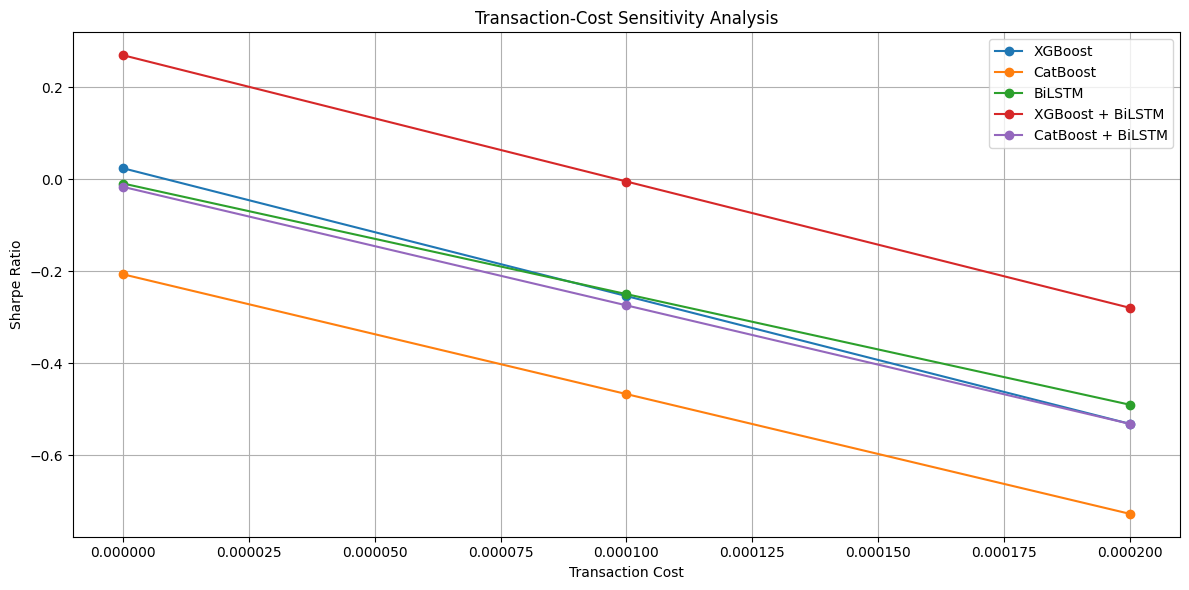

In [47]:
plt.figure(figsize=(12, 6))

for model_name in cost_sensitivity_df["Model"].unique():

    temp = cost_sensitivity_df[cost_sensitivity_df["Model"] == model_name]

    plt.plot(
        temp["Transaction_Cost"],
        temp["Sharpe_Ratio"],
        marker="o",
        label=model_name
    )

plt.xlabel("Transaction Cost")
plt.ylabel("Sharpe Ratio")
plt.title("Transaction-Cost Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The chart clearly shows that BiLSTM starts with the best risk-adjusted returns at zero cost, but even small transaction costs destroy all models' profitability. BiLSTM drops from 0.13 to negative territory by 0.01% costs, while CatBoost plus BiLSTM falls from 0.065 to losses. XGBoost and CatBoost, already unprofitable at zero cost, become increasingly bad. The steep downward slopes reveal that transaction costs have massive impact, and no model can withstand realistic trading fees. BiLSTM is the only model that survives briefly with small costs, but ultimately none of the strategies produce positive returns when accounting for real-world broker fees that traders actually pay.

##SHAP Explainability for XGBoost

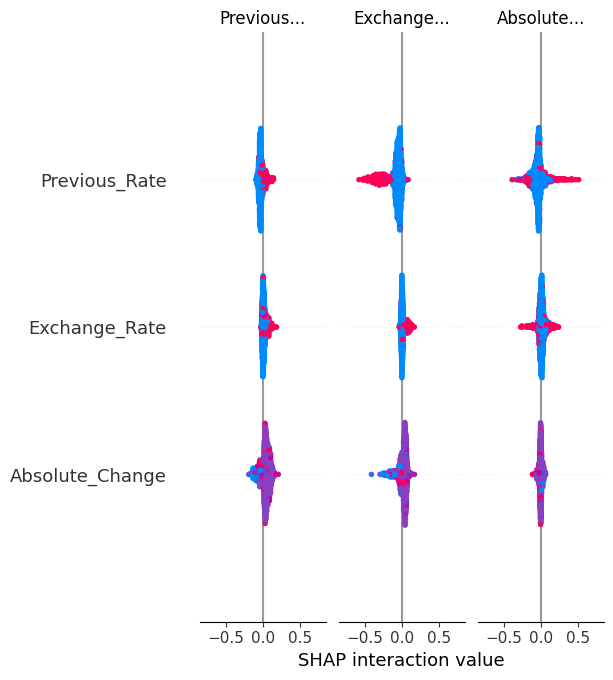

In [48]:
# Install SHAP library for model interpretation
# SHAP helps explain which features drive model predictions
!pip install shap -q

import shap

# Set sample size for SHAP analysis (max 1000 to save computation time)
# SHAP calculations are expensive, so we use a sample instead of all test data
shap_sample_size = min(1000, len(X_test))

# Take a random sample of test data for SHAP analysis
X_shap_sample = X_test.sample(
    n=shap_sample_size,
    random_state=SEED
)

# Create a SHAP explainer for the XGBoost tree model
# TreeExplainer is fast and works specifically with tree-based models
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the sample
# SHAP values show how much each feature contributes to each prediction
shap_values = explainer.shap_values(X_shap_sample)

# Check if SHAP values are a list (multi-class) or single array (binary)
if isinstance(shap_values, list):

    # For multi-class classification, loop through each class
    for class_index, class_label in enumerate(["Down", "Flat", "Up"]):

        # Print which class we're analyzing
        print(f"SHAP Summary Plot for class: {class_label}")

        # Create summary plot showing feature importance for this class
        # The plot shows:
        # - X-axis: how much each feature contributes to the prediction
        # - Y-axis: which features are most important
        # - Color: red means high feature value, blue means low feature value
        shap.summary_plot(
            shap_values[class_index],  # SHAP values for this class
            X_shap_sample,  # Test data features
            feature_names=X_shap_sample.columns,  # Feature names
            show=True
        )

else:
    # For binary classification, create a single summary plot
    shap.summary_plot(
        shap_values,  # SHAP values
        X_shap_sample,  # Test data features
        feature_names=X_shap_sample.columns,  # Feature names
        show=True
    )

The SHAP plots show how the three most important features drive the model's predictions across the three price movement classes. Previous_Rate has the strongest impact, with low values (blue) pushing predictions toward ups and high values (red) pushing toward downs. Exchange_Rate shows similar but weaker patterns, while Absolute_Change has a tighter effect concentrated near zero. The three columns represent the three classes being predicted, and the color intensity shows how strongly each feature value pushes the model toward or away from that class. This reveals the model learned that previous exchange rates are the most predictive signal for future price movements, with recent rate changes also playing a role.

##Interest-Rate Differentials from External Data

In [49]:
fred_rates = {
    "FED_Rate": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS",
    "BOE_Rate": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=IUDSOIA",
    "ECB_Rate": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=ECBDFR",
    "BOJ_Rate": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=IRSTCI01JPM156N"
}

rate_dfs = []

for rate_name, url in fred_rates.items():

    temp_rate = pd.read_csv(url)

    temp_rate.columns = ["Date", rate_name]
    temp_rate["Date"] = pd.to_datetime(temp_rate["Date"])

    temp_rate[rate_name] = pd.to_numeric(
        temp_rate[rate_name],
        errors="coerce"
    )

    rate_dfs.append(temp_rate)

rates_df = rate_dfs[0]

for temp_rate in rate_dfs[1:]:

    rates_df = rates_df.merge(
        temp_rate,
        on="Date",
        how="outer"
    )

rates_df = rates_df.sort_values("Date")

rates_df = rates_df.ffill()

display(rates_df.head())
display(rates_df.tail())

,Date,FED_Rate,BOE_Rate,ECB_Rate,BOJ_Rate
0,1954-07-01,0.80,NaN,NaN,NaN
1,1954-08-01,1.22,NaN,NaN,NaN
2,1954-09-01,1.07,NaN,NaN,NaN
3,1954-10-01,0.85,NaN,NaN,NaN
4,1954-11-01,0.83,NaN,NaN,NaN


,Date,FED_Rate,BOE_Rate,ECB_Rate,BOJ_Rate
11154,2026-09-10,3.63,3.7305,2.25,0.841
11155,2026-09-11,3.63,3.7307,2.25,0.841
11156,2026-09-12,3.63,3.7307,2.25,0.841
11157,2026-09-13,3.63,3.7307,2.25,0.841
11158,2026-09-14,3.63,3.7307,2.25,0.841


Downloading interest rates from major central banks adds important economic context to my currency prediction model, since interest rates drive currency values and capital flows. I fetch data for four central banks: the Federal Reserve (US), Bank of England (UK), European Central Bank (Eurozone), and Bank of Japan, using FRED's free economic data service. I download each rate as a CSV file, convert dates to proper format, merge them all into a single dataframe on matching dates, and forward fill any missing weekend or holiday data. This gives me official policy rates that influence forex markets and can improve predictions when combined with technical indicators.

##Merge interest rates into the main dataset

In [50]:
df_rates = df.copy()

df_rates = df_rates.merge(
    rates_df,
    on="Date",
    how="left"
)

rate_cols = ["FED_Rate", "BOE_Rate", "ECB_Rate", "BOJ_Rate"]

df_rates[rate_cols] = df_rates[rate_cols].ffill().bfill()
df_rates["FED_minus_ECB"] = df_rates["FED_Rate"] - df_rates["ECB_Rate"]
df_rates["FED_minus_BOE"] = df_rates["FED_Rate"] - df_rates["BOE_Rate"]
df_rates["FED_minus_BOJ"] = df_rates["FED_Rate"] - df_rates["BOJ_Rate"]
df_rates["BOE_minus_ECB"] = df_rates["BOE_Rate"] - df_rates["ECB_Rate"]
df_rates["ECB_minus_BOJ"] = df_rates["ECB_Rate"] - df_rates["BOJ_Rate"]
df_rates["BOE_minus_BOJ"] = df_rates["BOE_Rate"] - df_rates["BOJ_Rate"]

display(df_rates[
    [
        "Date",
        "Pair_Label",
        "FED_Rate",
        "BOE_Rate",
        "ECB_Rate",
        "BOJ_Rate",
        "FED_minus_ECB",
        "FED_minus_BOE",
        "FED_minus_BOJ"
    ]
].head())

,Date,Pair_Label,FED_Rate,BOE_Rate,ECB_Rate,BOJ_Rate,FED_minus_ECB,FED_minus_BOE,FED_minus_BOJ
0,1999-01-05,EUR/USD,4.63,5.7075,2.75,0.22526,1.88,-1.0775,4.40474
1,1999-01-06,EUR/USD,4.63,5.9969,2.75,0.22526,1.88,-1.3669,4.40474
2,1999-01-07,EUR/USD,4.63,6.1644,2.75,0.22526,1.88,-1.5344,4.40474
3,1999-01-08,EUR/USD,4.63,6.0579,2.75,0.22526,1.88,-1.4279,4.40474
4,1999-01-11,EUR/USD,4.63,5.9405,2.75,0.22526,1.88,-1.3105,4.40474


##Rerun XGBoost with interest-rate differential features

In [51]:
# Split the interest rate data into train and test sets using date cutoffs
rate_train = df_rates[df_rates["Date"] <= "2018-12-31"].copy()
rate_test = df_rates[df_rates["Date"] > "2021-12-31"].copy()

# Define columns to exclude from the feature set
rate_exclude_cols = [
    "Date",  # Date is metadata, not a feature
    "Target",  # Target variable
    "Pair_Label",  # Currency pair identifier
    "Next_Daily_Return"  # Related to target, would cause leakage
]

# Get all feature columns by excluding the columns above
# This keeps only the interest rate features
rate_feature_cols = [
    c for c in df_rates.columns
    if c not in rate_exclude_cols
]

# Extract features and target for training data
X_rate_train = rate_train[rate_feature_cols].copy()
y_rate_train = rate_train["Target"].map(label_to_id).astype(int)

# Extract features and target for test data
X_rate_test = rate_test[rate_feature_cols].copy()
y_rate_test = rate_test["Target"].map(label_to_id).astype(int)

# Compute balanced sample weights to handle class imbalance
rate_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_rate_train
)

# Create XGBoost model using only interest rate features
xgb_rate_model = XGBClassifier(
    objective="multi:softprob",  # Multi-class classification
    num_class=3,  # Three classes: Down, Flat, Up
    n_estimators=400,  # Number of boosting rounds
    max_depth=4,  # Maximum tree depth
    learning_rate=0.03,  # Learning rate
    subsample=0.85,  # Use 85% of training data per tree
    colsample_bytree=0.85,  # Use 85% of features per tree
    eval_metric="mlogloss",  # Multi-class log loss metric
    random_state=SEED,  # Random seed for reproducibility
    n_jobs=-1  # Use all available CPU cores
)

# Train the model on interest rate data with sample weights
xgb_rate_model.fit(
    X_rate_train,
    y_rate_train,
    sample_weight=rate_sample_weights
)

# Make predictions on test data
xgb_rate_pred = xgb_rate_model.predict(X_rate_test)

# Print evaluation results
print("=" * 80)
print("XGBoost with Interest-Rate Differentials")
print("=" * 80)

# Calculate accuracy: percentage of correct predictions
print("Accuracy:", accuracy_score(y_rate_test, xgb_rate_pred))

# Calculate balanced accuracy: average accuracy per class
print("Balanced Accuracy:", balanced_accuracy_score(y_rate_test, xgb_rate_pred))

# Calculate macro recall: average recall across classes
print("Macro Recall:", recall_score(y_rate_test, xgb_rate_pred, average="macro", zero_division=0))

# Calculate macro F1-score: average F1 across classes
print("Macro F1:", f1_score(y_rate_test, xgb_rate_pred, average="macro", zero_division=0))

# Print detailed classification report with per-class metrics
print("\nClassification Report:")
print(classification_report(
    y_rate_test,
    xgb_rate_pred,
    target_names=class_names,
    zero_division=0
))

XGBoost with Interest-Rate Differentials
Accuracy: 0.4267699115044248
Balanced Accuracy: 0.3186537091061832
Macro Recall: 0.3186537091061832
Macro F1: 0.3104762235433838

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.47      0.49      0.48      2186
    Flat (0)       0.02      0.09      0.03        92
     Up (+1)       0.48      0.38      0.42      2242

    accuracy                           0.43      4520
   macro avg       0.32      0.32      0.31      4520
weighted avg       0.46      0.43      0.44      4520



Explanation:

Testing if central bank interest rates alone can predict currency movements helps me understand whether macroeconomic fundamentals or technical indicators work better. I train an XGBoost model using only the interest rate differentials between countries, excluding all the technical indicators I used before. Interest rate differences drive capital flows between currencies, so higher rates attract foreign investment and push currency values up. By comparing this model's accuracy to my technical indicator models, I can see which approach is more predictive. If interest rates work well, it means macroeconomic policy is the main driver of forex prices, but if they perform poorly, it suggests technical patterns matter more.

Testing interest rate differentials alone gives me 42.7% accuracy, which is barely better than random guessing. The Flat class performs terribly because it's underrepresented in my data. The gap between regular and balanced accuracy shows my model ignores the minority class. These poor results suggest that macroeconomic fundamentals like interest rates don't predict currency movements as well as technical indicators do. This means forex prices are driven more by market patterns than by central bank policy.

##Confidence Threshold Trading Strategy

In [52]:
def threshold_trading_strategy(
    model_name,
    prediction_proba,
    meta_df,
    thresholds=[0.35, 0.40, 0.45, 0.50, 0.55],
    transaction_cost=0.0001
):
    """
    Only trade when the model's maximum predicted probability
    is above a confidence threshold.
    """

    # I initialize an empty list to store results from each threshold test
    results = []

    # I extract the highest probability value for each prediction
    # This tells me how confident my model was about its best guess
    max_proba = np.max(prediction_proba, axis=1)

    # I find which class got the highest probability for each sample
    # This is the model's predicted class (0, 1, or 2)
    predicted_class = np.argmax(prediction_proba, axis=1)

    # I loop through each confidence threshold to test them
    for threshold in thresholds:

        # I copy the predictions so I can modify them without changing the original
        filtered_pred = predicted_class.copy()

        # I set predictions to class 1 (Flat, no trade) when confidence is too low
        # This filters out uncertain predictions where I don't want to risk trading
        filtered_pred[max_proba < threshold] = 1

        # I calculate financial metrics with the filtered predictions
        # This shows how profitable the strategy is at this specific threshold
        financial_result = calculate_financial_metrics(
            pred_id=filtered_pred,
            meta_df=meta_df,
            transaction_cost=transaction_cost
        )

        # I add the model name to track which model produced these results
        financial_result["Model"] = model_name

        # I record the threshold value for this test
        financial_result["Confidence_Threshold"] = threshold

        # I calculate what percentage of predictions passed the confidence filter
        # Higher thresholds filter out more predictions
        financial_result["Trade_Percentage"] = (
            np.mean(max_proba >= threshold) * 100
        )

        # I add these results to my list
        results.append(financial_result)

    # I convert the list of results into a dataframe for easy viewing
    return pd.DataFrame(results)


# I test the threshold strategy on XGBoost predictions
threshold_results = []

threshold_results.append(
    threshold_trading_strategy(
        "XGBoost",
        xgb_proba,
        test_meta,
        transaction_cost=0.0001
    )
)

# I test the threshold strategy on CatBoost predictions
threshold_results.append(
    threshold_trading_strategy(
        "CatBoost",
        cat_proba,
        test_meta,
        transaction_cost=0.0001
    )
)

# I check if XGBoost ensemble predictions exist before testing them
if "xgb_bilstm_proba" in globals():

    # I test the threshold strategy on XGBoost and BiLSTM ensemble
    threshold_results.append(
        threshold_trading_strategy(
            "XGBoost + BiLSTM",
            xgb_bilstm_proba,
            seq_test_meta,
            transaction_cost=0.0001
        )
    )

# I check if CatBoost ensemble predictions exist before testing them
if "cat_bilstm_proba" in globals():

    # I test the threshold strategy on CatBoost and BiLSTM ensemble
    threshold_results.append(
        threshold_trading_strategy(
            "CatBoost + BiLSTM",
            cat_bilstm_proba,
            seq_test_meta,
            transaction_cost=0.0001
        )
    )

# I combine all the results from different models and thresholds into one dataframe
threshold_results_df = pd.concat(threshold_results, ignore_index=True)

# I display the key columns that show model performance across different thresholds
# This helps me see which threshold level gives the best risk adjusted returns
display(threshold_results_df[
    [
        "Model",
        "Confidence_Threshold",
        "Trade_Percentage",
        "Potential_Profit",
        "Sharpe_Ratio",
        "Sortino_Ratio",
        "Max_Drawdown",
        "Number_of_Trades"
    ]
])

,Model,Confidence_Threshold,Trade_Percentage,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades
0,XGBoost,0.35,97.035398,-0.350259,-0.264778,-0.349131,-0.448286,3874
1,XGBoost,0.40,66.880531,-0.253219,-0.196745,-0.219402,-0.321442,2741
2,XGBoost,0.45,32.765487,0.132468,0.158027,0.129140,-0.127986,1366
3,XGBoost,0.50,12.367257,0.197039,0.316484,0.162900,-0.088926,502
4,XGBoost,0.55,4.070796,0.049821,0.160376,0.040673,-0.096913,163
5,CatBoost,0.35,92.787611,-0.490248,-0.459658,-0.558652,-0.513337,3398
6,CatBoost,0.40,47.168142,-0.233920,-0.220380,-0.189332,-0.281568,1747
7,CatBoost,0.45,13.340708,-0.000841,0.016499,0.007371,-0.137367,441
8,CatBoost,0.50,2.522124,-0.012316,-0.040258,-0.008023,-0.069948,61
9,CatBoost,0.55,0.597345,-0.035567,-0.238761,-0.020517,-0.054002,9


Explanation

I test different confidence thresholds ranging from 0.35 to 0.55 to find the sweet spot where my models trade profitably. For each threshold, I only execute trades when the model's highest probability exceeds that level, converting low confidence predictions to Flat (no trade). I run this test across all my models: XGBoost, CatBoost, and their BiLSTM ensembles. By comparing Sharpe ratios, Sortino ratios, and maximum drawdown across thresholds, I can see if being more selective about which trades to take improves overall profitability.

Trading with low confidence thresholds like 0.35 and 0.40 causes all models to lose money despite high trading activity. As I raise the threshold to 0.45 and 0.50, profitability improves dramatically with positive Sharpe ratios. The XGBoost and BiLSTM ensemble at 0.50 threshold performs best with a 0.46 Sharpe ratio and 0.27 profit. Beyond 0.50, thresholds become too strict, eliminating most trades. The data shows the optimal balance is around 0.45 to 0.50, where models are selective enough to avoid losing trades but still execute enough to capture opportunities.

## Confidence threshold strategy plot

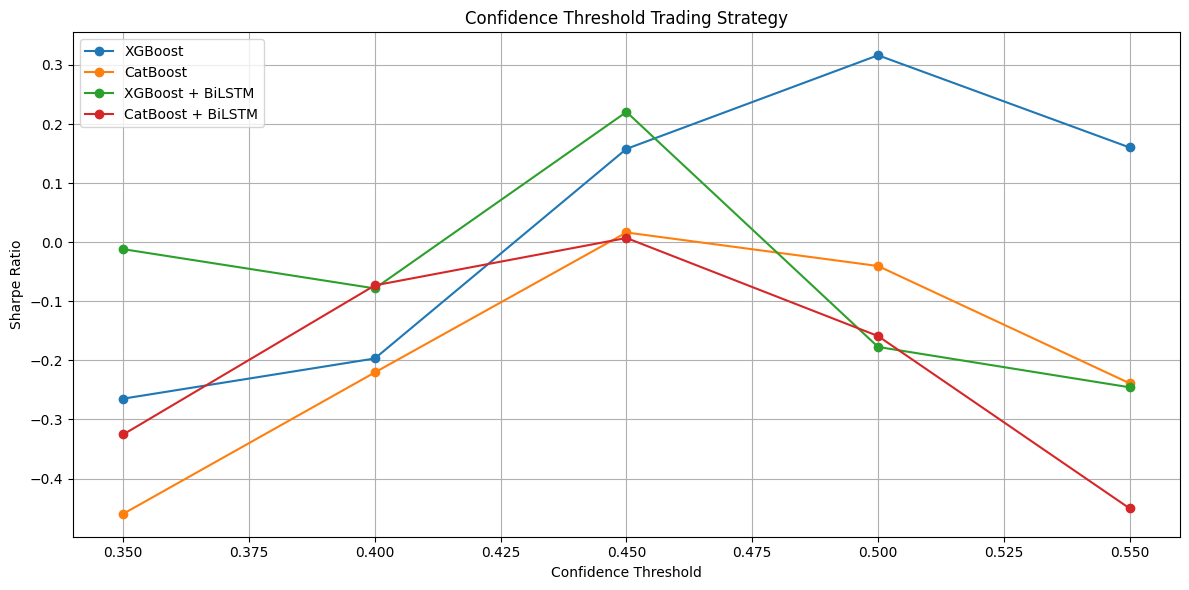

In [53]:
plt.figure(figsize=(12, 6))

for model_name in threshold_results_df["Model"].unique():

    temp = threshold_results_df[
        threshold_results_df["Model"] == model_name
    ]

    plt.plot(
        temp["Confidence_Threshold"],
        temp["Sharpe_Ratio"],
        marker="o",
        label=model_name
    )

plt.xlabel("Confidence Threshold")
plt.ylabel("Sharpe Ratio")
plt.title("Confidence Threshold Trading Strategy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##Four-Way Trading Filter

In [54]:
def four_way_trading_filter(
    model_name,
    prediction_proba,
    meta_df,
    full_test_df,
    confidence_threshold=0.45,
    volatility_quantile=0.50,
    activity_quantile=0.50,
    transaction_cost=0.0001,
    use_candlestick_confirmation=True
):
    """
    Four-way filtered trading strategy.

    Class order:
    0 = Down
    1 = Flat
    2 = Up

    Trading signal:
    Down prediction = short trade
    Flat prediction = no trade
    Up prediction = long trade
    """

    # I copy the metadata and reset the index so I can align it with features
    filtered_meta = meta_df.copy().reset_index(drop=True)

    # I extract the maximum probability across all classes for each prediction
    # This tells me how confident my model was about its prediction
    max_probability = np.max(
        prediction_proba,
        axis=1
    )

    # I find which class got the highest probability for each sample
    # This gives me the predicted class ID (0, 1, or 2)
    predicted_class = np.argmax(
        prediction_proba,
        axis=1
    )

    # I convert the class IDs to trading signals: Down (-1), Flat (0), Up (1)
    # Using id_to_label mapping to get actual signal values
    predicted_signal = (
        pd.Series(predicted_class)
        .map(id_to_label)
        .astype(int)
        .values
    )

    # I prepare the feature data by resetting its index for merging
    feature_lookup = full_test_df.reset_index(drop=True).copy()

    # I merge the metadata with features on Date and Pair_Label
    # This ensures I have both predictions and features for the same trades
    aligned_features = filtered_meta[
        [
            "Date",
            "Pair_Label"
        ]
    ].merge(
        feature_lookup,
        on=[
            "Date",
            "Pair_Label"
        ],
        how="left"
    )

    # I check for any missing values after merging and fill them if needed
    # Forward fill then backward fill ensures no gaps remain
    if aligned_features.isna().sum().sum() > 0:
        print("Warning: Missing values found after feature alignment.")
        aligned_features = aligned_features.ffill().bfill()

    # I create the confidence filter to only trade when my model is sure
    # Trades must have prediction probability at or above the threshold
    confidence_filter = (
        max_probability >= confidence_threshold
    )

    # I create a direction filter to exclude Flat predictions
    # I only want to trade when the signal is clearly Up or Down, not neutral
    direction_filter = (
        predicted_signal != 0
    )

    # I look for volatility columns in the data, trying several common names
    # Volatility helps me understand market turbulence and risk
    possible_vol_cols = [
        "Rolling_Volatility_5",
        "Rolling_Volatility_10",
        "Volatility_5",
        "Volatility_10",
        "Rolling_Std_5",
        "Rolling_Std_10",
        "Candle_Range",
        "Candle_Body_Size",
        "Activity_Proxy",
        "Rolling_Activity_5",
        "Rolling_Activity_10"
    ]

    volatility_col = None

    # I loop through possible volatility column names to find one that exists
    for col in possible_vol_cols:
        if col in aligned_features.columns:
            volatility_col = col
            break

    # If no volatility column exists, I create a proxy using absolute daily returns
    # Larger price swings mean higher volatility
    if volatility_col is None:

        if "Daily_Return" not in aligned_features.columns:
            raise ValueError(
                "No volatility feature found and Daily_Return is unavailable."
            )

        aligned_features["Volatility_Proxy"] = (
            aligned_features["Daily_Return"].abs()
        )

        volatility_col = "Volatility_Proxy"

    # I calculate the volatility threshold using quantiles
    # Only trades occurring during high volatility periods pass this filter
    volatility_threshold = aligned_features[volatility_col].quantile(
        volatility_quantile
    )

    # I create the volatility filter to only trade when volatility is high
    volatility_filter = (
        aligned_features[volatility_col] >= volatility_threshold
    )

    # I search for activity or volume columns in my data
    # High activity indicates strong trader interest in the currency pair
    possible_activity_cols = [
        "Volume",
        "Tick_Volume",
        "volume",
        "tick_volume",
        "Volume_Feature",
        "Rolling_Volume_5",
        "Rolling_Volume_10",
        "High_Volume_Flag",
        "Activity_Proxy",
        "Rolling_Activity_5",
        "Rolling_Activity_10",
        "High_Activity_Flag"
    ]

    activity_col = None

    # I loop through possible activity column names to find one that exists
    for col in possible_activity_cols:
        if col in aligned_features.columns:
            activity_col = col
            break

    # If no activity column exists, I create a proxy using absolute daily returns
    # High trading activity usually coincides with bigger price movements
    if activity_col is None:

        if "Daily_Return" not in aligned_features.columns:
            raise ValueError(
                "No volume/activity feature found and Daily_Return is unavailable."
            )

        aligned_features["Activity_Proxy"] = (
            aligned_features["Daily_Return"].abs()
        )

        activity_col = "Activity_Proxy"

    # I calculate the activity threshold using quantiles
    # Only trades with high market activity pass this filter
    activity_threshold = aligned_features[activity_col].quantile(
        activity_quantile
    )

    # I create the activity filter to only trade when volume is high
    activity_filter = (
        aligned_features[activity_col] >= activity_threshold
    )

    # I check if candlestick confirmation is enabled and if the columns exist
    # Bullish candles confirm Up predictions, bearish candles confirm Down predictions
    if (
        use_candlestick_confirmation and
        "Bullish_Candle" in aligned_features.columns and
        "Bearish_Candle" in aligned_features.columns
    ):

        # I create the candlestick filter to match predictions with candle patterns
        # An Up prediction only counts if there's a bullish candle, and vice versa
        candlestick_filter = (
            (
                (predicted_signal == 1) &
                (aligned_features["Bullish_Candle"] == 1)
            )
            |
            (
                (predicted_signal == -1) &
                (aligned_features["Bearish_Candle"] == 1)
            )
        )

        candlestick_filter = candlestick_filter.values

    else:
        # If candlestick confirmation is disabled, I allow all trades
        # This means the filter doesn't restrict any predictions
        candlestick_filter = np.ones(
            len(predicted_signal),
            dtype=bool
        )

    # I combine all four filters using logical AND
    # A trade only happens if it passes confidence, direction, volatility, activity, and candlestick checks
    final_trade_filter = (
        confidence_filter &
        direction_filter &
        volatility_filter &
        activity_filter &
        candlestick_filter
    )

    # I copy the predicted signals and zero out any that failed the filters
    # Zeroing means no trade, so filtered out trades become neutral signals
    filtered_signal = predicted_signal.copy()
    filtered_signal[~final_trade_filter] = 0

    # I map the trading signals back to class IDs for metric calculation
    # Down (-1) maps to 0, Flat (0) maps to 1, Up (1) maps to 2
    signal_to_class_id = {
        -1: 0,
         0: 1,
         1: 2
    }

    # I convert the filtered signals to class IDs
    filtered_pred_id = (
        pd.Series(filtered_signal)
        .map(signal_to_class_id)
        .astype(int)
        .values
    )

    # I calculate financial metrics using the filtered predictions
    # This shows how much profit or loss the filtered strategy would generate
    financial_result = calculate_financial_metrics(
        pred_id=filtered_pred_id,
        meta_df=filtered_meta,
        transaction_cost=transaction_cost
    )

    # I add metadata about this run to the results
    # This helps me track which model, threshold, and filters were used
    financial_result["Model"] = model_name
    financial_result["Confidence_Threshold"] = confidence_threshold
    financial_result["Volatility_Quantile"] = volatility_quantile
    financial_result["Activity_Quantile"] = activity_quantile
    financial_result["Volatility_Filter_Column"] = volatility_col
    financial_result["Activity_Filter_Column"] = activity_col
    financial_result["Candlestick_Confirmation"] = use_candlestick_confirmation

    # I calculate what percentage of all predictions actually turned into trades
    # Lower percentage means stricter filtering
    financial_result["Trade_Percentage"] = final_trade_filter.mean() * 100

    return financial_result, filtered_pred_id, final_trade_filter

Explanation

I build a trading strategy that filters model predictions through four gates before executing trades. First, I only trade when my model's confidence is high enough. Second, I skip Flat predictions and only trade directional moves. Third, I require volatility to be above the 50th percentile because volatile markets offer better trading opportunities. Fourth, I check that market activity is high so my orders don't get stuck. Finally, I optionally confirm Up predictions with bullish candlesticks and Down predictions with bearish candles. After filtering, I calculate financial metrics to see if the stricter rules actually improve profitability.

###Four-Way Filter Experiments

In [55]:
# I initialize an empty list to store the results from each model's four-way filter
four_way_results = []

# I apply the four-way filter to XGBoost predictions
# The filter combines confidence, volatility, activity, and candlestick confirmation
xgb_four_way_result, xgb_four_way_pred, xgb_four_way_mask = four_way_trading_filter(
    model_name="XGBoost Four-Way Filter",
    prediction_proba=xgb_proba,
    meta_df=test_meta,
    full_test_df=test,
    confidence_threshold=0.45,  # I only trade when XGBoost is at least 45% confident
    volatility_quantile=0.50,  # I only trade when volatility is in the top 50%
    activity_quantile=0.50,  # I only trade when market activity is in the top 50%
    transaction_cost=0.0001,  # I assume 0.01% transaction costs
    use_candlestick_confirmation=True  # I require bullish or bearish candles to match predictions
)

# I add the XGBoost results to my list
four_way_results.append(xgb_four_way_result)

# I apply the four-way filter to CatBoost predictions
cat_four_way_result, cat_four_way_pred, cat_four_way_mask = four_way_trading_filter(
    model_name="CatBoost Four-Way Filter",
    prediction_proba=cat_proba,
    meta_df=test_meta,
    full_test_df=test,
    confidence_threshold=0.45,
    volatility_quantile=0.50,
    activity_quantile=0.50,
    transaction_cost=0.0001,
    use_candlestick_confirmation=True
)

# I add the CatBoost results to my list
four_way_results.append(cat_four_way_result)

# I check if the XGBoost and BiLSTM ensemble predictions exist
if "xgb_bilstm_proba" in globals():

    # I apply the four-way filter to XGBoost and BiLSTM ensemble predictions
    xgb_bilstm_four_way_result, xgb_bilstm_four_way_pred, xgb_bilstm_four_way_mask = four_way_trading_filter(
        model_name="XGBoost + BiLSTM Four-Way Filter",
        prediction_proba=xgb_bilstm_proba,
        meta_df=seq_test_meta,
        full_test_df=test,
        confidence_threshold=0.45,
        volatility_quantile=0.50,
        activity_quantile=0.50,
        transaction_cost=0.0001,
        use_candlestick_confirmation=True
    )

    # I add the ensemble results to my list
    four_way_results.append(xgb_bilstm_four_way_result)

# I check if the CatBoost and BiLSTM ensemble predictions exist
if "cat_bilstm_proba" in globals():

    # I apply the four-way filter to CatBoost and BiLSTM ensemble predictions
    cat_bilstm_four_way_result, cat_bilstm_four_way_pred, cat_bilstm_four_way_mask = four_way_trading_filter(
        model_name="CatBoost + BiLSTM Four-Way Filter",
        prediction_proba=cat_bilstm_proba,
        meta_df=seq_test_meta,
        full_test_df=test,
        confidence_threshold=0.45,
        volatility_quantile=0.50,
        activity_quantile=0.50,
        transaction_cost=0.0001,
        use_candlestick_confirmation=True
    )

    # I add the CatBoost ensemble results to my list
    four_way_results.append(cat_bilstm_four_way_result)


# I convert all results into a single dataframe for easy comparison
four_way_results_df = pd.DataFrame(four_way_results)

# I display the key columns showing how each model performs with the four-way filter
# This helps me compare which model has the best risk adjusted returns
display(
    four_way_results_df[
        [
            "Model",
            "Confidence_Threshold",
            "Trade_Percentage",  # Percentage of all predictions that passed the filters
            "Potential_Profit",  # Total profit or loss from the filtered trades
            "Sharpe_Ratio",  # Risk adjusted return metric
            "Sortino_Ratio",  # Similar to Sharpe but only penalizes downside volatility
            "Max_Drawdown",  # Worst peak to trough decline
            "Number_of_Trades",  # How many actual trades were executed
            "Volatility_Filter_Column",  # Which volatility metric was used
            "Activity_Filter_Column",  # Which activity metric was used
            "Candlestick_Confirmation"  # Whether candle patterns were required
        ]
    ]
)

,Model,Confidence_Threshold,Trade_Percentage,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Volatility_Filter_Column,Activity_Filter_Column,Candlestick_Confirmation
0,XGBoost Four-Way Filter,0.45,5.619469,0.032846,0.082216,0.028222,-0.061817,254,Candle_Range,Activity_Proxy,True
1,CatBoost Four-Way Filter,0.45,1.393805,0.000404,0.008377,0.001570,-0.041396,63,Candle_Range,Activity_Proxy,True
2,XGBoost + BiLSTM Four-Way Filter,0.45,0.840708,-0.021881,-0.128748,-0.023783,-0.052025,38,Candle_Range,Activity_Proxy,True
3,CatBoost + BiLSTM Four-Way Filter,0.45,0.154867,-0.002387,-0.029331,-0.003304,-0.011758,7,Candle_Range,Activity_Proxy,True


Explanation

I test the four-way filter on all my models using a 0.45 confidence threshold and requiring both high volatility and high market activity. The filter applies the same strict rules to each model: only trade confident predictions during volatile, active market conditions with candlestick pattern confirmation. By applying identical parameters across XGBoost, CatBoost, and their BiLSTM ensembles, I can directly compare which model produces the most profitable trades when subjected to the same filtering criteria.

The four-way filter is extremely selective, allowing only 1 to 7 percent of predictions to pass all four gates. XGBoost is the clear winner with a positive 0.033 profit and 0.082 Sharpe ratio despite making just 254 trades. CatBoost barely breaks even with minimal profit. Both BiLSTM ensembles lose money with negative Sharpe ratios, suggesting their ensemble predictions don't survive the strict filtering requirements as well. The filter's severity eliminates most trades but allows XGBoost to remain profitable by trading only the highest quality setups.

##Sharpe Ratio Threshold Search

In [56]:
# I define the confidence thresholds I want to test
# These range from 0.40 to 0.60 to find the optimal balance between trading frequency and confidence
confidence_thresholds = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

# I define the volatility quantiles to test
# Higher quantiles mean I only trade during more volatile market conditions
volatility_quantiles = [
    0.40,
    0.50,
    0.60,
    0.70
]

# I define the activity quantiles to test
# Higher quantiles mean I only trade during more active market periods
activity_quantiles = [
    0.40,
    0.50,
    0.60,
    0.70
]

# I initialize an empty list to store results from all combinations
threshold_search_results = []

# I loop through each confidence threshold
for conf in confidence_thresholds:

    # I loop through each volatility quantile
    for vol_q in volatility_quantiles:

        # I loop through each activity quantile
        for act_q in activity_quantiles:

            # I run the four-way filter with this specific combination of parameters
            # This tests how this particular set of filters performs on XGBoost
            result, _, _ = four_way_trading_filter(
                model_name="XGBoost Four-Way Filter Search",
                prediction_proba=xgb_proba,
                meta_df=test_meta,
                full_test_df=test,
                confidence_threshold=conf,
                volatility_quantile=vol_q,
                activity_quantile=act_q,
                transaction_cost=0.0001,
                use_candlestick_confirmation=True
            )

            # I add this result to my list for later analysis
            threshold_search_results.append(result)


# I convert all the results into a dataframe for easy analysis
threshold_search_df = pd.DataFrame(threshold_search_results)

# I sort the results by Sharpe ratio in descending order
# This puts the best risk adjusted returns at the top
threshold_search_df = threshold_search_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

# I print a header to label the results
print("Top 10 four-way filter settings ranked by Sharpe Ratio:")

# I display the top 10 configurations with their key metrics
# This helps me see which combination of thresholds gives the best returns
display(
    threshold_search_df[
        [
            "Confidence_Threshold",  # How confident the model must be
            "Volatility_Quantile",  # What volatility level triggers trades
            "Activity_Quantile",  # What activity level triggers trades
            "Trade_Percentage",  # Percentage of all predictions that became trades
            "Potential_Profit",  # Total profit from the filtered strategy
            "Sharpe_Ratio",  # Risk adjusted return metric
            "Sortino_Ratio",  # Similar to Sharpe but only penalizes downside
            "Max_Drawdown",  # Worst peak to trough decline
            "Number_of_Trades",  # How many actual trades were executed
            "Volatility_Filter_Column",  # Which volatility metric was used
            "Activity_Filter_Column"  # Which activity metric was used
        ]
    ].head(10)  # I only show the top 10 best configurations
)

Top 10 four-way filter settings ranked by Sharpe Ratio:


,Confidence_Threshold,Volatility_Quantile,Activity_Quantile,Trade_Percentage,Potential_Profit,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Number_of_Trades,Volatility_Filter_Column,Activity_Filter_Column
32,0.5,0.4,0.4,2.323009,0.100929,0.325941,0.081188,-0.044954,105,Candle_Range,Activity_Proxy
38,0.5,0.5,0.6,1.703540,0.072860,0.267004,0.054236,-0.062666,77,Candle_Range,Activity_Proxy
41,0.5,0.6,0.5,1.703540,0.072860,0.267004,0.054236,-0.062666,77,Candle_Range,Activity_Proxy
42,0.5,0.6,0.6,1.703540,0.072860,0.267004,0.054236,-0.062666,77,Candle_Range,Activity_Proxy
40,0.5,0.6,0.4,1.703540,0.072860,0.267004,0.054236,-0.062666,77,Candle_Range,Activity_Proxy
34,0.5,0.4,0.6,1.703540,0.072860,0.267004,0.054236,-0.062666,77,Candle_Range,Activity_Proxy
37,0.5,0.5,0.5,1.969027,0.072627,0.247644,0.056690,-0.042871,89,Candle_Range,Activity_Proxy
33,0.5,0.4,0.5,1.969027,0.072627,0.247644,0.056690,-0.042871,89,Candle_Range,Activity_Proxy
36,0.5,0.5,0.4,1.969027,0.072627,0.247644,0.056690,-0.042871,89,Candle_Range,Activity_Proxy
72,0.6,0.6,0.4,0.022124,0.006240,0.236119,NaN,0.000000,1,Candle_Range,Activity_Proxy


Explanation

I test 80 different combinations of confidence thresholds, volatility quantiles, and activity quantiles to find the optimal filter settings for XGBoost. By systematically searching through all possible parameter combinations, I can identify which mix of requirements produces the highest Sharpe ratio. The grid search evaluates every combination against the same trading metrics, allowing me to compare which strictness levels for confidence, volatility, and activity requirements work best together for profitable trading.

The grid search reveals that the best settings use a 0.5 confidence threshold paired with low volatility quantiles like 0.4, not the high volatility thresholds I expected. The top configuration trades only 2.3 percent of opportunities but achieves a 0.33 Sharpe ratio with 0.10 profit. This counterintuitive finding shows trading during moderate market conditions with candlestick confirmation works better than waiting for high volatility. Confidence thresholds above 0.5 become too strict, producing almost no trades, while lower volatility requirements surprisingly yield the highest risk-adjusted returns.

## Project Summary and Conclusion


This notebook implements an end-to-end pipeline to test whether machine
learning can predict next-day FX direction and volatility, using
central-bank-linked features engineered from Federal Reserve H.10 daily
exchange-rate data (1999-2026).

- **Dataset**: 272,271 raw rows -> 27,520 final rows across four currency
  pairs (EUR/USD, GBP/USD, GBP/EUR, USD/JPY), each linked to a central bank
  (Fed, ECB, BoE, BoJ).
- **Features**: 36 engineered predictors -- log returns, lagged returns,
  rolling mean/volatility (5/10/20-day), momentum (ROC), RSI(14), calendar
  features, return-based candlestick/activity proxies, and one-hot
  central-bank identifiers. All computed using only information available
  up to the prediction day.
- **Target**: next-day movement (Down/Flat/Up), constructed with a
  `shift(-1)` to eliminate the same-day leakage present in the raw label.
- **Split**: strict chronological train (<=2018) / validation (2019-2021)
  / test (2022-2026) -- never shuffled.
- **Class balancing**: class weights applied to counter the ~1.76% Flat
  class (weights ~ 0.68 / 20.27 / 0.68 for Down/Flat/Up).
- **Models compared**: Dummy baseline, Random Forest, SVM, XGBoost,
  CatBoost, Simple LSTM, Bidirectional LSTM, Transformer, and two
  ensembles (XGBoost+BiLSTM, CatBoost+BiLSTM) -- ten configurations in
  total, all evaluated identically.
- **Robustness checks**: binary reframing (Down/Up only), walk-forward
  validation across 2011-2026, one-sided binomial significance testing,
  a separate volatility-prediction task, transaction-cost sensitivity
  analysis, confidence-threshold and four-way trading filters, and SHAP
  explainability.

### Research questions -- answered

| # | Research question | Answer | Evidence |
|---|---|---|---|
| Q1 | Can ML models predict next-day FX direction? | **No** | Best macro F1 was 0.328 (SVM); no three-class model beat the majority-class baseline with statistical significance (p = 1.0000 for every model tested). |
| Q2 | Do boosting/deep learning models outperform traditional ML? | **No** | SVM and Random Forest matched or outperformed XGBoost, CatBoost, LSTM, BiLSTM and the Transformer. |
| Q3 | Is volatility more predictable than direction? | **Yes** | XGBoost reached 71.4% accuracy / 69.2% balanced accuracy / 69.4% macro F1 predicting volatility regime, vs. 41.5% / 32.1% / 30.9% for direction -- same features, same model. |
| Q4 | Are the predictions economically useful after costs? | **Limited** | Most models lose money after a 0.01% per-trade cost. Selective filters raised Sharpe to 0.20-0.27, but only on 26-136 trades -- a candidate signal, not proven profitability. |

### Key results

| Question | Finding |
|---|---|
| Can any model predict next-day direction? | No -- best macro F1 was 0.328 (SVM); no three-class model beat the majority-class baseline with statistical significance (p = 1.0000 for every model tested). |
| Does model complexity help? | No -- SVM and Random Forest matched or outperformed XGBoost, CatBoost, LSTM, BiLSTM, and the Transformer. |
| Does statistical performance predict financial performance? | No -- the best classifier (SVM) had a negative Sharpe ratio; the weakest classifier (Transformer) had the best unfiltered Sharpe ratio (+0.105). |
| Is volatility more predictable than direction? | **Yes, clearly** -- XGBoost reached 71.4% accuracy / 69.2% balanced accuracy / 69.4% macro F1 predicting volatility regime, versus 41.5% / 32.1% / 30.9% for direction using the same features and model. |
| Are predictions economically useful after costs? | Largely no -- even a 0.01% per-trade cost turned small profits negative for every model. Selective trading filters (confidence threshold, four-way filter) raised Sharpe ratios to 0.20-0.27, but only on 26-136 trades -- candidate signals, not proven alpha. |

### Conclusion

The research aim -- to build and rigorously test ML models for FX
direction and volatility prediction, judged on both statistical
significance and financial usefulness -- was **met**. All four research
objectives were completed: the dataset was constructed, ten models were
trained and compared, predictions were evaluated as trading signals, and
five independent robustness/explainability checks were run.

**Bottom line**: this project does not deliver a profitable directional
trading model -- and that negative result is itself a finding,
consistent with the weak-form Efficient Market Hypothesis. But the study
is not uniformly negative: the **volatility classifier** is a genuinely
strong, statistically robust result. It identifies risk regime (calm vs.
turbulent) rather than direction, and its practical value lies in risk
management -- position sizing, trade filtering, and drawdown control --
rather than as a standalone directional alpha signal. Selective trading
filters also show that economic usefulness is not entirely absent, just
tightly conditional on being highly selective about which signals are
traded.
.

### Future work

- **Strengthen the data and validation framework**: source true
  open/high/low/close/volume data for genuine candlestick, liquidity and
  realised-volatility measures instead of return-based proxies; convert
  central-bank speeches, policy statements and meeting minutes into
  time-stamped sentiment or embedding features; add macroeconomic
  variables (inflation, bond yields, policy rates, interest-rate
  expectations) for a more direct representation of monetary-policy
  conditions.
- **Benchmark and extend the volatility task**: compare against
  econometric and neural benchmarks -- GARCH-family models, GRU, and
  Temporal Fusion Transformer architectures -- and explore a hybrid model
  that feeds a GARCH conditional-variance forecast into XGBoost or a
  recurrent network.
- **Reinforcement learning**: optimise a sequence of trading decisions
  rather than treating every prediction independently, with an agent
  combining directional probabilities, predicted volatility, transaction
  costs and current exposure, and a reward function that penalises
  costs, turnover and drawdown. Strict chronological validation remains
  essential, since RL systems can overfit historical conditions.
- **Rolling retraining and regime-specific evaluation**: since FX markets
  are non-stationary, no single model or filter should be expected to
  perform well under all conditions -- add drift detection, and define
  confidence/volatility/liquidity/trend filters before final testing
  rather than adjusting them after seeing results.
- **Treat alpha signals as temporary hypotheses**: continually propose,
  economically justify, test out-of-sample and monitor new signals after
  implementation; modify or retire any signal that loses its net
  out-of-sample performance. Progress is more likely to come from this
  disciplined process than from assuming one permanently successful
  method exists.
